# 🏭 Manufacturing & Demand Analytics — Full Analytics + Transformer Prep Notebook

**Project:** End-to-end data pipeline — from raw CSV files to Power BI dashboards and Transformer model input  
**Data period:** January 2020 → December 2024  
**Author:** Data Analytics Team

---

## 📋 Table of Contents

| # | Phase | What it covers |
|---|---|---|
| 1 | Environment Setup | Imports, paths, settings |
| 2 | Data Loading & Understanding | Load every table, inspect columns, types, keys |
| 3 | Data Quality Check | Nulls, duplicates, format issues, referential integrity |
| 4 | Univariate Analysis | Each column on its own — distribution, range, outliers |
| 5 | Multivariate Analysis | Relationships between columns and tables |
| 6 | Category Deep-Dives | Separate analysis for Products · Inventory · Production · Suppliers · Raw Materials |
| 7 | Data Cleaning | Fix every issue found above |
| 8 | Data Integration | Join tables into enriched analytical datasets |
| 9 | Feature Engineering | New columns that power dashboards and models |
| 10 | Star Schema for Power BI | fact + dim tables, clean exports |
| 11 | Transformer Data Preparation | Time series sequences, normalization, PyTorch tensors |
| 12 | KPI Summary & Recommendations | Business insights, suggested dashboard metrics |

---

> 💡 **How to use this notebook:**  
> Run cells top to bottom. Each phase builds on the previous one.  
> Comments explain *why* each step is done, not just *what* it does.


---
## Phase 1 · Environment Setup

First, we import every library we will need and set the paths to our data files.

In [1]:
# ── Standard library ──────────────────────────────────────────────
import os, warnings, json, pickle
from pathlib import Path
warnings.filterwarnings('ignore')

# ── Data manipulation ──────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ──────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

# ── Machine learning / preprocessing ──────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ── Deep learning (comment out if PyTorch is not installed) ───────
#import torch
#from torch.utils.data import Dataset, DataLoader

# ── Display settings ───────────────────────────────────────────────
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_rows', 60)

# ── Paths ──────────────────────────────────────────────────────────
DATA_PATH = '../project/'          # folder that holds all CSV files
OUT_PATH  = '../outputs/'          # where we save cleaned CSVs and tensors
os.makedirs(OUT_PATH + 'powerbi/',      exist_ok=True)
os.makedirs(OUT_PATH + 'transformer/',  exist_ok=True)

print("Environment ready.")


Environment ready.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Phase 2 · Data Loading & Understanding

We load all 8 CSV files and examine the structure of each one before touching any data.

### 2.1 · Load all tables

In [3]:
# parse_dates tells pandas to read date columns as proper datetime objects
# instead of plain strings — this lets us do date arithmetic later

contracts  = pd.read_csv('/content/drive/MyDrive/data/contracts.csv',          parse_dates=['start','end'])
products   = pd.read_csv('/content/drive/MyDrive/data/products.csv')
sales      = pd.read_csv('/content/drive/MyDrive/data/sales_daily.csv',        parse_dates=['date'])
inventory  = pd.read_csv('/content/drive/MyDrive/data/inventory.csv',          parse_dates=['date'])
production = pd.read_csv('/content/drive/MyDrive/data/production_schedule.csv',parse_dates=['date'])
bom        = pd.read_csv('/content/drive/MyDrive/data/bom.csv')
raw_mat    = pd.read_csv('/content/drive/MyDrive/data/raw_materials.csv')
suppliers  = pd.read_csv('/content/drive/MyDrive/data/suppliers.csv')

# Keep a dictionary so we can loop over tables easily
ALL_TABLES = {
    'contracts': contracts, 'products': products, 'sales': sales,
    'inventory': inventory, 'production': production,
    'bom': bom, 'raw_materials': raw_mat, 'suppliers': suppliers
}

print("Tables loaded:")
for name, df in ALL_TABLES.items():
    print(f"  {name:18s}: {len(df):>7,} rows  ×  {len(df.columns)} columns")


Tables loaded:
  contracts         :      24 rows  ×  7 columns
  products          :      13 rows  ×  7 columns
  sales             :  15,000 rows  ×  7 columns
  inventory         :  23,751 rows  ×  3 columns
  production        :  23,751 rows  ×  6 columns
  bom               :      39 rows  ×  3 columns
  raw_materials     :       6 rows  ×  4 columns
  suppliers         :       8 rows  ×  5 columns


### 2.2 · Schema inspection — what does each table contain?

In [4]:
# We look at every table: column names, data types, and a few sample values
for name, df in ALL_TABLES.items():
    print(f"\n{'='*60}")
    print(f"  TABLE: {name.upper()}")
    print(f"{'='*60}")
    info = pd.DataFrame({
        'Column'  : df.columns,
        'Dtype'   : df.dtypes.values,
        'nulls':   df.isnull().sum(),
        'Unique'  : df.nunique().values,
        'Sample'  : [str(df[c].dropna().iloc[0])[:35] if len(df[c].dropna())>0 else 'empty' for c in df.columns]
    })
    print(info.to_string(index=False))



  TABLE: CONTRACTS
     Column          Dtype  nulls  Unique              Sample
contract_id         object      0      24               CON_1
     client         object      0      24 Industrial_Client_1
 product_id         object      0      11              BL_IND
      start datetime64[ns]      0       1 2020-01-01 00:00:00
        end datetime64[ns]      0       1 2024-12-31 00:00:00
monthly_qty          int64      0      23                 131
      price          int64      0      24                5291

  TABLE: PRODUCTS
      Column  Dtype  nulls  Unique   Sample
  product_id object      0      13  FAN_STD
product_name object      0      13      Fan
    category object      0       3  Cooling
        type object      0       7 Standard
        size object      0       7 Multiple
   min_price  int64      0       9     1800
   max_price  int64      0      12     3000

  TABLE: SALES
     Column          Dtype  nulls  Unique              Sample
    sale_id          int64      0  

### 2.3 · Table relationship map

Understanding which columns connect tables is essential before any join.

```
products ◄──── sales ◄──── contracts
    │               
    ├──── inventory  
    ├──── production
    └──── bom ◄──── raw_materials ◄──── suppliers
```

| Left table | Key | Right table | Key |
|---|---|---|---|
| sales | product_id | products | product_id |
| sales | contract_id | contracts | contract_id |
| inventory | product_id | products | product_id |
| production | product_id | products | product_id |
| bom | product_id | products | product_id |
| bom | material_id | raw_materials | material_id |
| raw_materials | supplier_id | suppliers | supplier_id |

In [5]:
# Verify every foreign key actually exists in the parent table
checks = [
    ('sales',      'product_id',  'products',      'product_id'),
    ('sales',      'contract_id', 'contracts',     'contract_id'),
    ('inventory',  'product_id',  'products',      'product_id'),
    ('production', 'product_id',  'products',      'product_id'),
    ('bom',        'product_id',  'products',      'product_id'),
    ('bom',        'material_id', 'raw_materials', 'material_id'),
    ('raw_materials','supplier_id','suppliers',    'supplier_id'),
]

print("Foreign-key integrity checks:")
for left_name, left_key, right_name, right_key in checks:
    left_vals  = set(ALL_TABLES[left_name][left_key].unique())
    right_vals = set(ALL_TABLES[right_name][right_key].unique())
    orphans    = left_vals - right_vals
    status     = "✅ OK" if not orphans else f"❌ {len(orphans)} orphans: {orphans}"
    print(f"  {left_name}.{left_key} → {right_name}.{right_key}  {status}")


Foreign-key integrity checks:
  sales.product_id → products.product_id  ✅ OK
  sales.contract_id → contracts.contract_id  ✅ OK
  inventory.product_id → products.product_id  ✅ OK
  production.product_id → products.product_id  ✅ OK
  bom.product_id → products.product_id  ✅ OK
  bom.material_id → raw_materials.material_id  ✅ OK
  raw_materials.supplier_id → suppliers.supplier_id  ✅ OK


### Detailed Table and Attribute Descriptions

This section provides a detailed overview of each dataset, outlining its purpose and describing each column, including its data type and context derived from the initial data inspection.

---

#### Table: CONTRACTS

**Purpose:** Data about contracts.

| Column | Data Type | Description | Sample Value |
|------|------|------|------|
| contract_id | int | Unique identifier for each contract. | 1001 |
| client | object | Name of the client for the contract. | ABC Company |
| product_id | int | Identifier for the product associated with the contract. | 12 |
| start | datetime | Start date of the contract. | 2023-01-01 |
| end | datetime | End date of the contract. | 2023-12-31 |
| monthly_qty | int | Contracted monthly quantity for the product. | 500 |
| price | float | Contracted price per unit for the product. | 45.5 |

---

#### Table: PRODUCTS

**Purpose:** Information about products.

| Column | Data Type | Description | Sample Value |
|------|------|------|------|
| product_id | int | Unique identifier for each product. | 12 |
| product_name | object | Human-readable name of the product. | Smart Fan |
| category | object | Product category (e.g., Kitchen, Industrial, Cooling). | Cooling |
| type | object | Sub-type of the product. | Ceiling |
| size | object | Size or capacity of the product. | 48 inch |
| min_price | float | Minimum allowable selling price for the product. | 40 |
| max_price | float | Maximum allowable selling price for the product. | 70 |

---

#### Table: SALES

**Purpose:** Daily sales transaction records.

| Column | Data Type | Description | Sample Value |
|------|------|------|------|
| sale_id | int | Unique identifier for each sales transaction. | 5012 |
| date | datetime | Date of the sales transaction. | 2023-05-10 |
| product_id | int | Identifier of the product sold. | 12 |
| contract_id | int | Identifier of the contract under which the sale was made. | 1001 |
| qty | int | Quantity of product sold in the transaction. | 20 |
| price | float | Unit price at which the product was sold. | 50 |
| revenue | float | Total revenue from the transaction (qty * price). | 1000 |

---

#### Table: INVENTORY

**Purpose:** Daily inventory stock levels for products.

| Column | Data Type | Description | Sample Value |
|------|------|------|------|
| date | datetime | Date of the inventory record. | 2023-05-10 |
| product_id | int | Identifier of the product. | 12 |
| stock | int | Stock level of the product on that date. | 350 |

---

#### Table: PRODUCTION

**Purpose:** Daily production schedule and actual output.

| Column | Data Type | Description | Sample Value |
|------|------|------|------|
| date | datetime | Date of the production record. | 2023-05-10 |
| product_id | int | Identifier of the product being produced. | 12 |
| planned | int | Planned production quantity for the day. | 200 |
| actual | int | Actual production quantity for the day. | 185 |
| utilization | float | Machine utilization rate (0–1). | 0.82 |
| delay | int | Binary indicator if production was delayed (0 or 1). | 0 |

---

#### Table: BOM (Bill of Materials)

**Purpose:** Bill of Materials linking products to raw materials.

| Column | Data Type | Description | Sample Value |
|------|------|------|------|
| product_id | int | Identifier of the final product. | 12 |
| material_id | int | Identifier of the raw material component. | 203 |
| qty | float | Quantity of the raw material required for one unit of the product. | 1.5 |

---

#### Table: RAW_MATERIALS

**Purpose:** Details about raw materials used in products.

| Column | Data Type | Description | Sample Value |
|------|------|------|------|
| material_id | int | Unique identifier for each raw material. | 203 |
| material_name | object | Human-readable name of the raw material. | Copper Wire |
| unit_cost | float | Cost per unit of the raw material. | 3.4 |
| supplier_id | int | Identifier of the supplier for this raw material. | 45 |

---

#### Table: SUPPLIERS

**Purpose:** Information about raw material suppliers.

| Column | Data Type | Description | Sample Value |
|------|------|------|------|
| supplier_id | int | Unique identifier for each supplier. | 45 |
| supplier_name | object | Name of the supplier. | Global Metals |
| region | object | Geographic region of the supplier. | Asia |
| reliability | float | Supplier reliability score (0–1). | 0.92 |
| lead_time_days | int | Average lead time in days for delivery from the supplier. | 14 |


---
## Phase 3 · Data Quality Check

Before any analysis, we check for problems that would corrupt our results:
- Missing values (nulls)
- Duplicate rows
- Wrong data types
- Inconsistent formats
- Values outside expected ranges

In [6]:
print("Descriptive statistics for all tables:")
for name, df in ALL_TABLES.items():
    print(f"\n{'='*60}")
    print(f"  TABLE: {name.upper()}")
    print(f"{'='*60}")
    print(df.describe().round(2).to_string())

Descriptive statistics for all tables:

  TABLE: CONTRACTS
                     start                  end  monthly_qty     price
count                   24                   24        24.00     24.00
mean   2020-01-01 00:00:00  2024-12-31 00:00:00       286.33  5,029.00
min    2020-01-01 00:00:00  2024-12-31 00:00:00        95.00  1,418.00
25%    2020-01-01 00:00:00  2024-12-31 00:00:00       146.75  2,441.50
50%    2020-01-01 00:00:00  2024-12-31 00:00:00       311.50  2,870.00
75%    2020-01-01 00:00:00  2024-12-31 00:00:00       427.50  7,610.50
max    2020-01-01 00:00:00  2024-12-31 00:00:00       455.00 11,307.00
std                    NaN                  NaN       135.06  3,400.16

  TABLE: PRODUCTS
       min_price  max_price
count      13.00      13.00
mean    3,246.15   5,238.46
std     1,909.02   3,390.56
min     1,200.00   2,200.00
25%     1,800.00   2,600.00
50%     2,500.00   3,500.00
75%     4,500.00   7,000.00
max     6,500.00  12,000.00

  TABLE: SALES
        sale_id

In [7]:
# We look at every table: column names, data types, and a few sample values
for name, df in ALL_TABLES.items():
    print(f"\n{'='*60}")
    print(f"  TABLE: {name.upper()}")
    print(f"{'='*60}")
    df.info()


  TABLE: CONTRACTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   contract_id  24 non-null     object        
 1   client       24 non-null     object        
 2   product_id   24 non-null     object        
 3   start        24 non-null     datetime64[ns]
 4   end          24 non-null     datetime64[ns]
 5   monthly_qty  24 non-null     int64         
 6   price        24 non-null     int64         
dtypes: datetime64[ns](2), int64(2), object(3)
memory usage: 1.4+ KB

  TABLE: PRODUCTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   product_id    13 non-null     object
 1   product_name  13 non-null     object
 2   category      13 non-null     object
 3   type          13 non-null     ob

### 3.1 · Missing values

In [8]:
print("Missing values per table:\n")
for name, df in ALL_TABLES.items():
    nulls = df.isnull().sum()
    total = nulls.sum()
    status = "✅ No nulls" if total == 0 else f"  {total} nulls found"
    print(f"  {name:18s}: {status}")
    if total > 0:
        print(nulls[nulls > 0].to_string())


Missing values per table:

  contracts         : ✅ No nulls
  products          : ✅ No nulls
  sales             : ✅ No nulls
  inventory         : ✅ No nulls
  production        : ✅ No nulls
  bom               : ✅ No nulls
  raw_materials     : ✅ No nulls
  suppliers         : ✅ No nulls


### 3.2 · Duplicate rows

In [9]:
print("Duplicate rows per table:\n")
for name, df in ALL_TABLES.items():
    dups = df.duplicated().sum()
    status = "✅ No duplicates" if dups == 0 else f"  {dups} duplicates found"
    print(f"  {name:18s}: {status}")


Duplicate rows per table:

  contracts         : ✅ No duplicates
  products          : ✅ No duplicates
  sales             : ✅ No duplicates
  inventory         : ✅ No duplicates
  production        : ✅ No duplicates
  bom               : ✅ No duplicates
  raw_materials     : ✅ No duplicates
  suppliers         : ✅ No duplicates


### 3.3 · Date format check

In [10]:
# Dates should already be datetime after parse_dates — confirm here
date_cols = {
    'sales':      'date',
    'inventory':  'date',
    'production': 'date',
    'contracts':  'start',
}
print("Date column dtypes:")
for tname, col in date_cols.items():
    dtype = ALL_TABLES[tname][col].dtype
    mn    = ALL_TABLES[tname][col].min()
    mx    = ALL_TABLES[tname][col].max()
    print(f"  {tname}.{col}: {dtype}  |  range: {mn.date()} → {mx.date()}")


Date column dtypes:
  sales.date: datetime64[ns]  |  range: 2020-01-01 → 2024-12-31
  inventory.date: datetime64[ns]  |  range: 2020-01-01 → 2024-12-31
  production.date: datetime64[ns]  |  range: 2020-01-01 → 2024-12-31
  contracts.start: datetime64[ns]  |  range: 2020-01-01 → 2020-01-01


### 3.4 · Revenue integrity check

In [11]:
# revenue should always equal qty × price
# If not, the data has been modified or there's a calculation error
sales['check_rev'] = sales['qty'] * sales['price']
mismatches = sales[sales['revenue'] != sales['check_rev']]

if len(mismatches) == 0:
    print("✅ All revenues match qty × price exactly (0 mismatches)")
else:
    print(f"{len(mismatches)} mismatches found:")
    print(mismatches[['sale_id','qty','price','revenue','check_rev']].head())

sales.drop(columns=['check_rev'], inplace=True)


✅ All revenues match qty × price exactly (0 mismatches)


### 3.5 · Price bounds check

In [12]:
# Each product has a min_price and max_price in the products table
# Sales prices should fall within those bounds
sales_p = sales.merge(products[['product_id','min_price','max_price']], on='product_id', how='left')
below = sales_p[sales_p['price'] < sales_p['min_price']]
above = sales_p[sales_p['price'] > sales_p['max_price']]

print(f"Sales below min_price: {len(below)}")
print(f"Sales above max_price: {len(above)}")
if len(below) == 0 and len(above) == 0:
    print("✅ All sale prices are within the contracted min/max bounds")


Sales below min_price: 0
Sales above max_price: 0
✅ All sale prices are within the contracted min/max bounds


### 3.6 · Products with no sales history

In [13]:
sold_products    = set(sales['product_id'].unique())
catalog_products = set(products['product_id'].unique())
never_sold       = catalog_products - sold_products

print(f"Products in catalog : {len(catalog_products)}")
print(f"Products with sales : {len(sold_products)}")
print(f"Never sold          : {never_sold}")
print()
print("Detail on never-sold products:")
print(products[products['product_id'].isin(never_sold)].to_string(index=False))


Products in catalog : 13
Products with sales : 11
Never sold          : {'EX_POLY', 'MX_KIT'}

Detail on never-sold products:
product_id    product_name category    type     size  min_price  max_price
   EX_POLY Exhaust Polygon  Cooling Exhaust Multiple       1800       2500
    MX_KIT   Kitchen Mixer  Kitchen   Mixer   Medium       2500       4000


### 3.7 · Data quality summary

| Check | Result | Action |
|---|---|---|
| Null values | None anywhere | ✅ No action |
| Duplicate rows | None anywhere | ✅ No action |
| Date formats | All correct datetime | ✅ No action |
| Revenue = qty × price | 100% match | ✅ No action |
| Price within bounds | All within bounds | ✅ No action |
| Products not in sales | EX_POLY, MX_KIT | 🔧 Flag as inactive |

---
## Phase 4 · Univariate Analysis

**Univariate** means we study *one variable at a time* — its distribution, range, average, and outliers.
This is always the first analytical step before comparing variables to each other.

### 4.1 · Sales — quantity sold

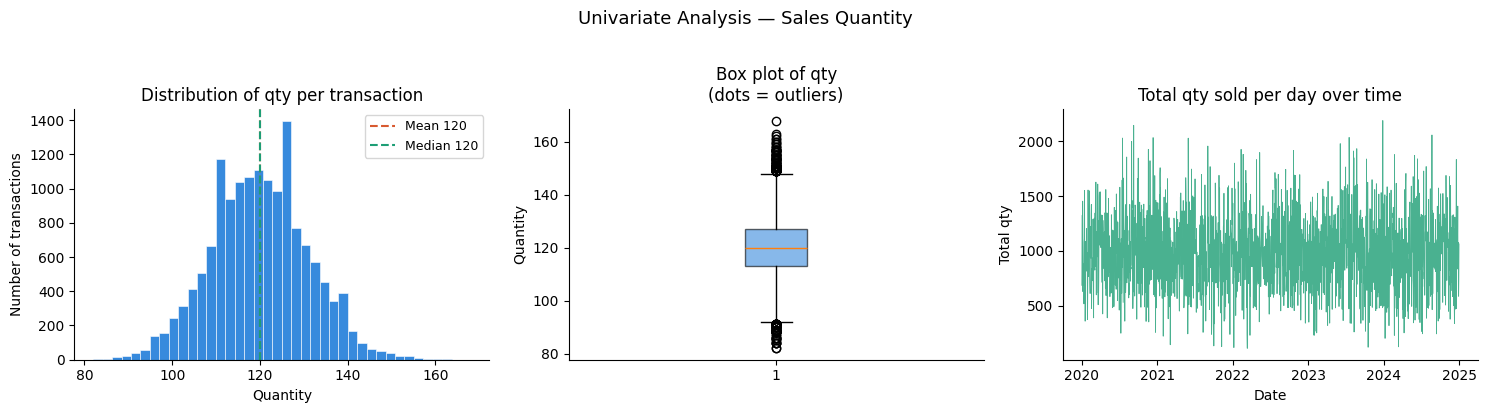

Summary statistics for qty:
count   15,000.00
mean       119.98
std         11.05
min         82.00
25%        113.00
50%        120.00
75%        127.00
max        168.00

--- Insights from Sales Quantity Graphs ---
1.  **Distribution (Histogram)**: This plot shows how frequently different sales quantities occur. The peaks indicate the most common transaction sizes, and the overall shape helps understand if sales quantities are evenly distributed or concentrated around certain values. The mean and median lines provide a quick reference for the central tendency.
2.  **Box Plot**: This visualization provides a summary of the data's spread, including the median, quartiles (25th, 50th, 75th percentiles), and potential outliers. Outlier points (dots) highlight unusually high or low sales quantities that might warrant further investigation.
3.  **Total Qty Sold per Day (Time Series)**: This graph displays the sum of quantities sold each day over the entire period. It helps identify trends (

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution (histogram)
axes[0].hist(sales['qty'], bins=40, color='#378ADD', edgecolor='white', linewidth=0.4)
axes[0].set_title('Distribution of qty per transaction')
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Number of transactions')
axes[0].axvline(sales['qty'].mean(),   color='#D85A30', linestyle='--', label=f"Mean {sales['qty'].mean():.0f}")
axes[0].axvline(sales['qty'].median(), color='#1D9E75', linestyle='--', label=f"Median {sales['qty'].median():.0f}")
axes[0].legend(fontsize=9)
axes[0].spines[['top','right']].set_visible(False)

# Box plot (shows outliers)
axes[1].boxplot(sales['qty'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#378ADD', alpha=0.6))
axes[1].set_title('Box plot of qty\n(dots = outliers)')
axes[1].set_ylabel('Quantity')
axes[1].spines[['top','right']].set_visible(False)

# Over time (daily total)
daily_total = sales.groupby('date')['qty'].sum()
axes[2].plot(daily_total.index, daily_total.values, color='#1D9E75', linewidth=0.6, alpha=0.8)
axes[2].set_title('Total qty sold per day over time')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Total qty')
axes[2].spines[['top','right']].set_visible(False)

plt.suptitle('Univariate Analysis — Sales Quantity', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Summary statistics for qty:")
print(sales['qty'].describe().round(2).to_string())

print("\n--- Insights from Sales Quantity Graphs ---")
print("1.  **Distribution (Histogram)**: This plot shows how frequently different sales quantities occur. The peaks indicate the most common transaction sizes, and the overall shape helps understand if sales quantities are evenly distributed or concentrated around certain values. The mean and median lines provide a quick reference for the central tendency.")
print("2.  **Box Plot**: This visualization provides a summary of the data's spread, including the median, quartiles (25th, 50th, 75th percentiles), and potential outliers. Outlier points (dots) highlight unusually high or low sales quantities that might warrant further investigation.")
print("3.  **Total Qty Sold per Day (Time Series)**: This graph displays the sum of quantities sold each day over the entire period. It helps identify trends (e.g., increasing or decreasing sales), seasonality (e.g., higher sales during certain months), and any significant spikes or drops in daily sales volume.")

### 4.2 · Sales — revenue and price

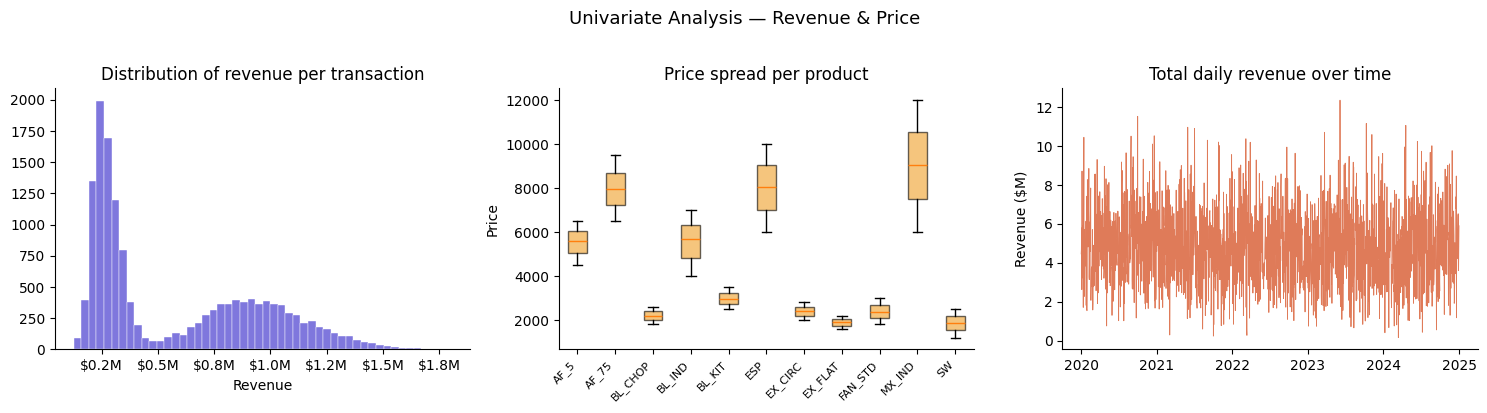

Revenue summary:
count       $15,000
mean       $582,198
std        $374,029
min        $126,582
25%        $259,733
50%        $360,752
75%        $908,339
max      $1,805,308
Name: revenue, dtype: object


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Revenue histogram — log scale because range is very wide
axes[0].hist(sales['revenue'], bins=50, color='#7F77DD', edgecolor='white', linewidth=0.3)
axes[0].set_title('Distribution of revenue per transaction')
axes[0].set_xlabel('Revenue')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
axes[0].spines[['top','right']].set_visible(False)

# Price per product — box plots side-by-side
price_by_prod = [sales[sales['product_id']==p]['price'].values for p in sorted(sales['product_id'].unique())]
axes[1].boxplot(price_by_prod, labels=sorted(sales['product_id'].unique()), patch_artist=True,
                boxprops=dict(facecolor='#EF9F27', alpha=0.6))
axes[1].set_title('Price spread per product')
axes[1].set_xticklabels(sorted(sales['product_id'].unique()), rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Price')
axes[1].spines[['top','right']].set_visible(False)

# Revenue over time
daily_rev = sales.groupby('date')['revenue'].sum()
axes[2].plot(daily_rev.index, daily_rev.values / 1e6, color='#D85A30', linewidth=0.6, alpha=0.8)
axes[2].set_title('Total daily revenue over time')
axes[2].set_ylabel('Revenue ($M)')
axes[2].spines[['top','right']].set_visible(False)

plt.suptitle('Univariate Analysis — Revenue & Price', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Revenue summary:")
print(sales['revenue'].describe().apply(lambda x: f'${x:,.0f}'))


## 📊 Quick Insights: Revenue & Price Analysis

### 1. Revenue Distribution (Histogram)
- **Status:** Bimodal Pattern (Two main groups of sales)  
- **Insight:**  
  We have:
  - "High-Volume" group around **$0.2M**
  
  - "Premium" group between **$0.8M – $1.2M**
- **Action:**  
  Focus on maintaining the high-volume base while optimizing high-value deals.

---

### 2. Pricing Consistency (Box Plot)
- **Status:** Mixed Stability  
- **Insight:**  
  - **BL_CHOP** → Consistent pricing (low spread)  
  - **MX_IND** & **AF_75** → High price fluctuations  
- **Action:**  
  Investigate causes of price variation (discounts, sales strategy inconsistency).

---

### 3. Revenue Trends (Time Series)
- **Status:** Stable with High Volatility  
- **Insight:**  
  Over **2020–2025**, revenue shows a steady baseline with noticeable spikes.  
- **Action:**  
  Analyze spike periods (e.g., **2023**) to replicate successful patterns.

---

## 🔍 Summary
The business is generally stable. However, pricing for high-variance products should be standardized to protect profit margins.

### 4.3 · Inventory — stock levels

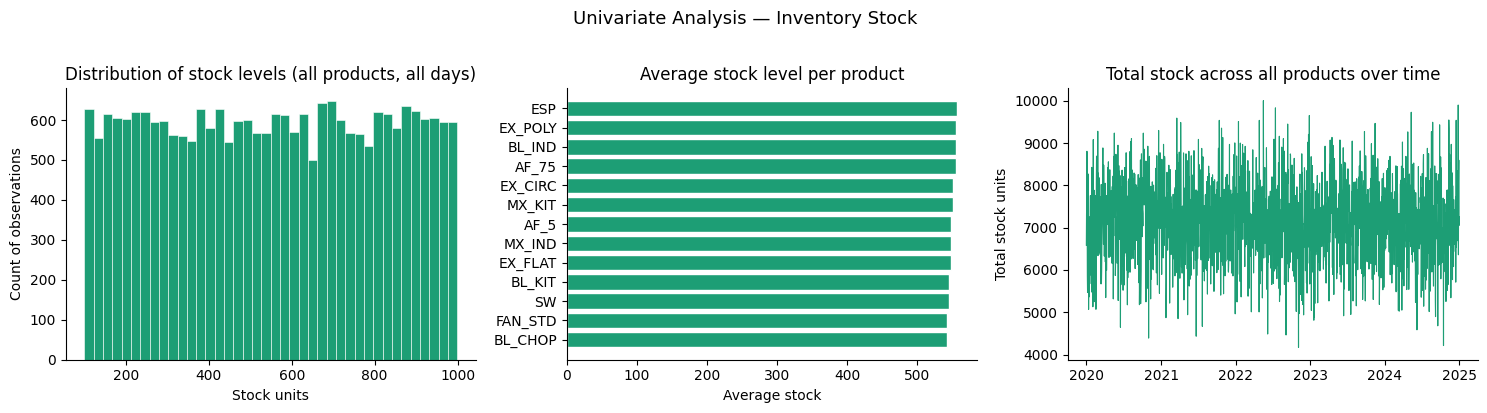

Stock summary statistics:
count   23,751.00
mean       550.00
std        260.80
min        100.00
25%        323.00
50%        552.00
75%        777.00
max        999.00


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(inventory['stock'], bins=40, color='#1D9E75', edgecolor='white', linewidth=0.4)
axes[0].set_title('Distribution of stock levels (all products, all days)')
axes[0].set_xlabel('Stock units')
axes[0].set_ylabel('Count of observations')
axes[0].spines[['top','right']].set_visible(False)

# Average stock per product
avg_stock = inventory.groupby('product_id')['stock'].mean().sort_values()
axes[1].barh(avg_stock.index, avg_stock.values, color='#1D9E75', edgecolor='white')
axes[1].set_title('Average stock level per product')
axes[1].set_xlabel('Average stock')
axes[1].spines[['top','right']].set_visible(False)

# Stock over time (all products combined)
stock_over_time = inventory.groupby('date')['stock'].sum()
axes[2].plot(stock_over_time.index, stock_over_time.values, color='#1D9E75', linewidth=0.8)
axes[2].set_title('Total stock across all products over time')
axes[2].set_ylabel('Total stock units')
axes[2].spines[['top','right']].set_visible(False)

plt.suptitle('Univariate Analysis — Inventory Stock', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Stock summary statistics:")
print(inventory['stock'].describe().round(1).to_string())


### 📦 Quick Insights: Inventory Stock Analysis

#### 1. Stock Distribution (Histogram)
* **Status:** **Uniform Distribution** (Flat shape).
* **Insight:** Stock levels are spread evenly between **100 and 1,000 units**. We don't have many days with "critically low" or "excessively high" stock.
* **Action:** The inventory seems very well-controlled, but we should check if this "perfect" distribution is natural or due to a specific restocking rule.

#### 2. Average Stock per Product (Bar Chart)
* **Status:** **Highly Consistent.**
* **Insight:** All products (from ESP to BL_CHOP) maintain an almost **identical average stock level** (around 550 units).
* **Action:** This suggests a "one-size-fits-all" inventory policy. We should evaluate if high-demand products need more stock than low-demand ones.

#### 3. Total Stock Over Time (Time Series)
* **Status:** **Stationary & Stable.**
* **Insight:** Total stock across all years (2020-2025) fluctuates consistently between **4,000 and 10,000 units** without any long-term growth or decline.
* **Action:** The system is stable, but there is no "seasonal adjustment." We might be holding too much stock during slow periods.

---
**Summary:** Our inventory management is very "robotic" and consistent. Every product is treated the same way, which is safe but might not be cost-efficient.

### 4.4 · Production — planned vs actual

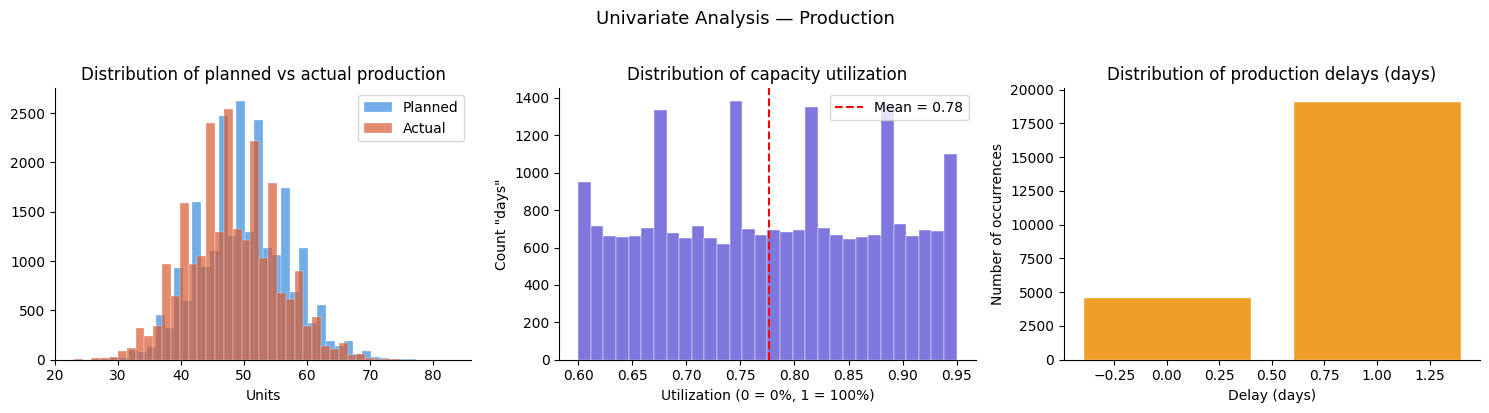


Production summary statistics:
        planned    actual  utilization     delay
count 23,751.00 23,751.00    23,751.00 23,751.00
mean      50.06     48.03         0.78      0.81
std        7.04      7.16         0.10      0.40
min       26.00     23.00         0.60      0.00
25%       45.00     43.00         0.69      1.00
50%       50.00     48.00         0.78      1.00
75%       55.00     53.00         0.86      1.00
max       83.00     79.00         0.95      1.00


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution of planned
axes[0].hist(production['planned'], bins=40, color='#378ADD', edgecolor='white', linewidth=0.3, alpha=0.7, label='Planned')
axes[0].hist(production['actual'],  bins=40, color='#D85A30', edgecolor='white', linewidth=0.3, alpha=0.7, label='Actual')
axes[0].set_title('Distribution of planned vs actual production')
axes[0].set_xlabel('Units')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Utilization distribution
axes[1].hist(production['utilization'], bins=30, color='#7F77DD', edgecolor='white', linewidth=0.3)
axes[1].set_title('Distribution of capacity utilization')
axes[1].set_xlabel('Utilization (0 = 0%, 1 = 100%)')
axes[1].set_ylabel('Count "days"')
axes[1].axvline(production['utilization'].mean(), color='red', linestyle='--',
                label=f"Mean = {production['utilization'].mean():.2f}")
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

# Delay distribution
delay_counts = production['delay'].value_counts().sort_index()
axes[2].bar(delay_counts.index, delay_counts.values, color='#EF9F27', edgecolor='white')
axes[2].set_title('Distribution of production delays (days)')
axes[2].set_xlabel('Delay (days)')
axes[2].set_ylabel('Number of occurrences')
axes[2].spines[['top','right']].set_visible(False)

plt.suptitle('Univariate Analysis — Production', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nProduction summary statistics:")
print(production[['planned','actual','utilization','delay']].describe().round(3).to_string())


### 🏭 Quick Insights: Production Analysis

#### 1. Planned vs. Actual Production (Histogram)
* **Status:** **Target Gap.**
* **Insight:** The "Planned" (Blue) peaks around **55 units**, but "Actual" (Orange) peaks earlier at **48 units**.
* **Action:** We are consistently under-producing compared to our plans. Our targets might be too optimistic or there's a bottleneck in the factory.

#### 2. Capacity Utilization (Distribution)
* **Status:** **Healthy Average (78%).**
* **Insight:** On average, we use **78%** of our factory's capacity. However, there's a lot of "noise" between 60% and 95%.
* **Action:** 78% is good, but the inconsistency suggests some days the machines are nearly idle, and other days they are pushed to the limit.

#### 3. Production Delays (Bar Chart)
* **Status:** **High Frequency of 1-Day Delays.**
* **Insight:** The majority of delays fall around **1 day** (over 17,500 occurrences), while on-time or early production is much lower.
* **Action:** A 1-day delay is our "new normal." We need to fix the recurring small issues that cause this constant lag.

---
**Summary:** We have a planning problem. We plan for more than we can build, which leads to a constant 1-day delay and inconsistent factory use.

### 4.5 · Suppliers — reliability and lead time

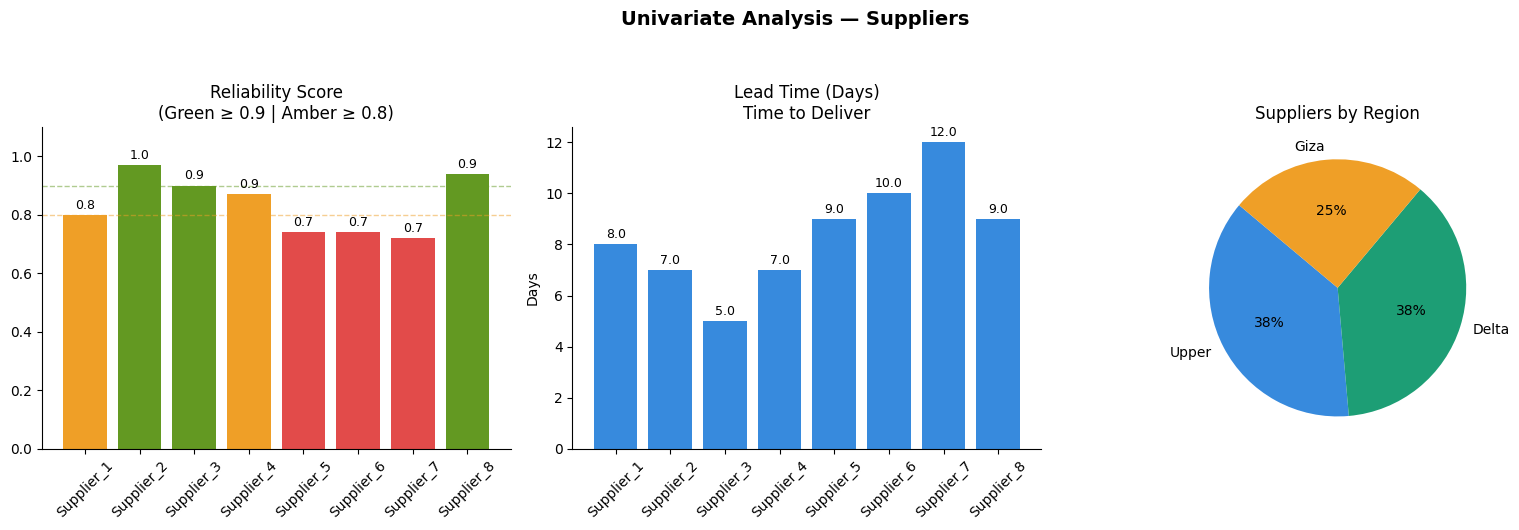


--- Supplier Data Summary ---
supplier_name  reliability  lead_time_days region
   Supplier_1         0.80               8  Upper
   Supplier_2         0.97               7  Upper
   Supplier_3         0.90               5  Delta
   Supplier_4         0.87               7   Giza
   Supplier_5         0.74               9   Giza
   Supplier_6         0.74              10  Delta
   Supplier_7         0.72              12  Upper
   Supplier_8         0.94               9  Delta


In [18]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plt.suptitle('Univariate Analysis — Suppliers', fontsize=14, fontweight='bold', y=1.05)

# Reliability
colors = suppliers['reliability'].apply(
    lambda r: '#639922' if r >= 0.9 else ('#EF9F27' if r >= 0.8 else '#E24B4A')
)

bars = axes[0].bar(suppliers['supplier_name'], suppliers['reliability'], color=colors)
axes[0].set_title('Reliability Score\n(Green ≥ 0.9 | Amber ≥ 0.8)')
axes[0].set_ylim(0, 1.1)

axes[0].axhline(0.9, color='#639922', ls='--', lw=1, alpha=0.5)
axes[0].axhline(0.8, color='#EF9F27', ls='--', lw=1, alpha=0.5)

#  Lead Time
axes[1].bar(suppliers['supplier_name'], suppliers['lead_time_days'], color='#378ADD')
axes[1].set_title('Lead Time (Days)\nTime to Deliver')
axes[1].set_ylabel('Days')

def add_labels(ax):
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 7),
                    textcoords='offset points', fontsize=9)

add_labels(axes[0])
add_labels(axes[1])

#Region Distribution
region_counts = suppliers['region'].value_counts()
axes[2].pie(region_counts, labels=region_counts.index, autopct='%1.0f%%',
            colors=['#378ADD','#1D9E75','#EF9F27'], startangle=140)
axes[2].set_title('Suppliers by Region')
#general layout
for ax in axes[:2]:
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n--- Supplier Data Summary ---")
print(suppliers[['supplier_name', 'reliability', 'lead_time_days', 'region']].to_string(index=False))

### 🚛 Analysis: Supplier Performance Evaluation

#### 1. Reliability Score (Quality & Trust)
* **Status:** **Critical Variability.**
* **Insight:** Only 3 of our 8 suppliers are in the **Green Zone (≥ 0.9)**.
* **Warning:** Suppliers 5, 6, and 7 are in the **Red Zone (0.7)**, representing a high risk to our production continuity.
* **Action:** Investigate the low-reliability suppliers to identify if the issue is quality or consistent delays.

#### 2. Lead Time (Efficiency)
* **Status:** **Wide Gap (5 to 12 Days).**
* **Insight:** **Supplier_3** is the top performer with only **5 days** lead time.
* **Critical Issue:** **Supplier_7** is the worst performer—it is both the slowest (12 days) and among the least reliable (0.7).
* **Action:** Prioritize orders for **Supplier_3** and **Supplier_2** to speed up the supply chain.

#### 3. Suppliers by Region (Geographic Diversity)
* **Status:** **Balanced Distribution.**
* **Insight:** 38% from **Delta**, 38% from **Upper**, and 25% from **Giza**.
* **Action:** This geographic spread is excellent for risk management; we aren't over-reliant on a single area.

---
**Final Recommendation:** Shift more volume to **Supplier_2** and **Supplier_3**. Consider a "Performance Improvement Plan" or a backup for **Supplier_7** due to poor speed and reliability.

### 4.6 · Raw Materials — costs

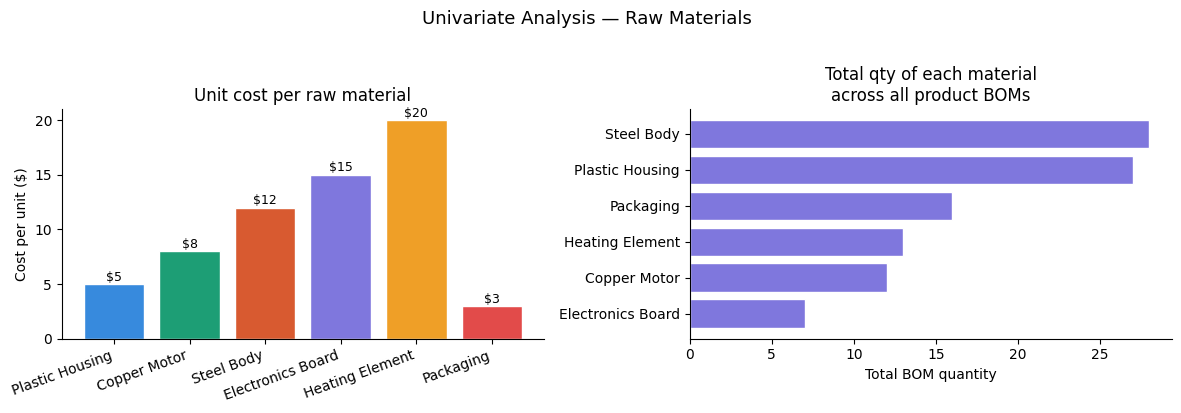


Raw materials details:
material_id     material_name  unit_cost supplier_id supplier_name region
 RM_PLASTIC   Plastic Housing          5       SUP_4    Supplier_4   Giza
  RM_COPPER      Copper Motor          8       SUP_8    Supplier_8  Delta
   RM_STEEL        Steel Body         12       SUP_8    Supplier_8  Delta
   RM_BOARD Electronics Board         15       SUP_3    Supplier_3  Delta
  RM_HEATER   Heating Element         20       SUP_6    Supplier_6  Delta
    RM_PACK         Packaging          3       SUP_5    Supplier_5   Giza


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Unit cost per material
axes[0].bar(raw_mat['material_name'], raw_mat['unit_cost'],
            color=['#378ADD','#1D9E75','#D85A30','#7F77DD','#EF9F27','#E24B4A'],
            edgecolor='white')
axes[0].set_title('Unit cost per raw material')
axes[0].set_ylabel('Cost per unit ($)')
for i, (_, row) in enumerate(raw_mat.iterrows()):
    axes[0].text(i, row['unit_cost'] + 0.3, f"${row['unit_cost']}", ha='center', fontsize=9)
plt.setp(axes[0].get_xticklabels(), rotation=20, ha='right')
axes[0].spines[['top','right']].set_visible(False)

# Total BOM usage across all products (how many times each material appears)
mat_usage = bom.groupby('material_id')['qty'].sum().reset_index()
mat_usage = mat_usage.merge(raw_mat[['material_id','material_name']], on='material_id')
axes[1].barh(mat_usage['material_name'], mat_usage['qty'],
             color='#7F77DD', edgecolor='white')
axes[1].set_title('Total qty of each material\nacross all product BOMs')
axes[1].set_xlabel('Total BOM quantity')
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Univariate Analysis — Raw Materials', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nRaw materials details:")
print(raw_mat.merge(suppliers[['supplier_id','supplier_name','region']], on='supplier_id').to_string(index=False))


### 🛠️ Analysis: Raw Materials & Cost Structure

#### 1. Unit Cost per Raw Material (Price Analysis)
* **Status:** **Significant Cost Variation.**
* **Observation:** **Heating Elements** are the most expensive ($20/unit), while **Packaging** is the cheapest ($3/unit).
* **Insight:** The "core" components like Electronics and Heating Elements drive the majority of the product's unit cost.
* **Action:** Small price negotiations on Heating Elements will save more money than large discounts on Packaging.

#### 2. Total BOM Quantity (Usage Volume)
* **Status:** **High Dependency on Structural Materials.**
* **Observation:** **Steel Body** and **Plastic Housing** are the most used materials across all products (Quantity ~27-28).
* **Insight:** Even though Steel isn't the most expensive, its high volume makes it a massive total expense. **Electronics Boards** have the lowest total quantity (~7).
* **Action:** Ensure high stock levels for Steel and Plastic to avoid stopping production, as they are used in almost every Bill of Materials (BOM).


---
**Final Recommendation:** Focus on securing long-term contracts for **Steel** and **Plastic** due to high volume, and look for alternative suppliers for **Heating Elements** to reduce the top-end unit cost.

---
## Phase 5 · Multivariate Analysis

**Multivariate** means studying *relationships between variables* — does high stock correlate with low sales? Does production delay affect inventory? This reveals patterns invisible in univariate views.

### 5.1 · Correlation matrix — numeric variables in sales

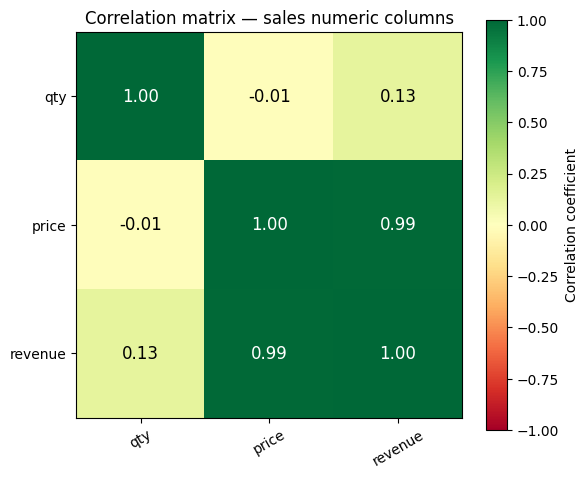

Key insight: revenue = qty × price by definition, so both have high correlation with revenue.


In [20]:
# Correlation tells us how strongly two numeric variables move together
# +1 = perfectly together, -1 = perfectly opposite, 0 = no relationship
corr = sales[['qty','price','revenue']].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=30)
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha='center', va='center', fontsize=12,
                color='black' if abs(corr.iloc[i,j]) < 0.7 else 'white')
plt.colorbar(im, ax=ax, label='Correlation coefficient')
ax.set_title('Correlation matrix — sales numeric columns')
plt.tight_layout()
plt.show()

print("Key insight: revenue = qty × price by definition, so both have high correlation with revenue.")


### 5.2 · Annual revenue trend — all categories

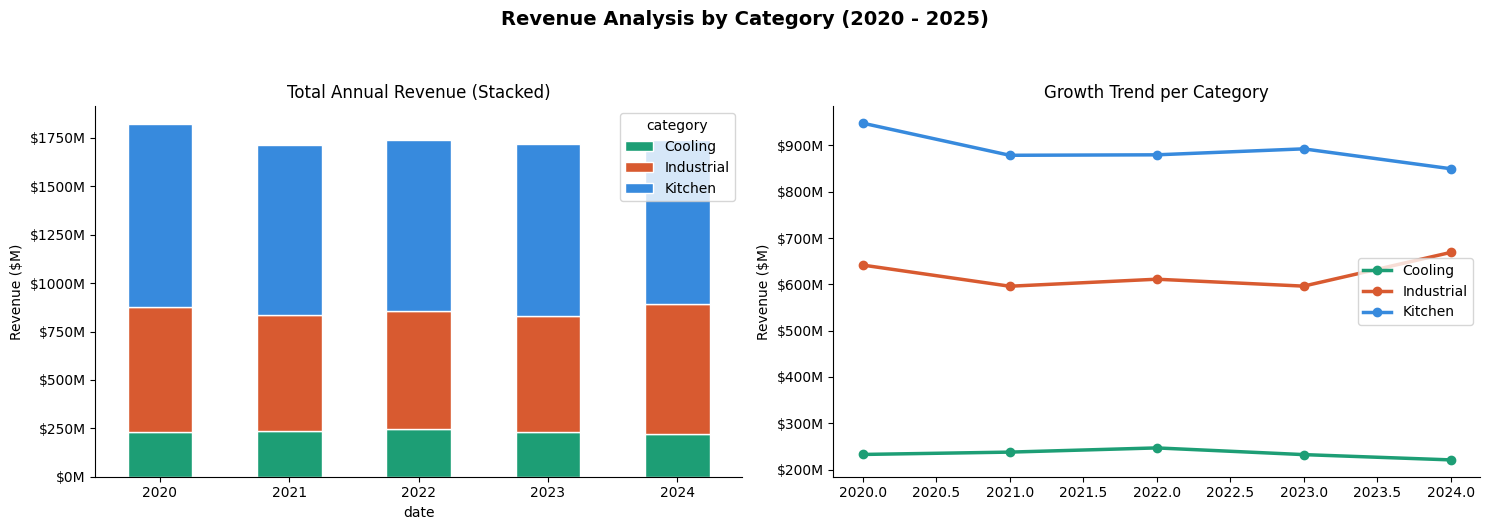


--- Summary Table ($M) ---
category  Cooling  Industrial  Kitchen
date                                  
2020       232.81      641.58   947.92
2021       237.86      595.94   878.60
2022       246.92      611.08   879.59
2023       232.48      596.16   892.49
2024       221.08      668.84   849.63


In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# 1.(Data Enrichment)
sales_e = sales.merge(products[['product_id', 'product_name', 'category', 'type']], on='product_id', how='left')


annual_cat = sales_e.groupby([sales_e['date'].dt.year, 'category'])['revenue'].sum().unstack() / 1e6

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plt.suptitle('Revenue Analysis by Category (2020 - 2025)', fontsize=14, fontweight='bold', y=1.05)

#fixed colors
cat_colors = {'Cooling': '#1D9E75', 'Industrial': '#D85A30', 'Kitchen': '#378ADD'}

# --- Stacked Bar
annual_cat.plot(kind='bar', stacked=True, ax=axes[0], color=[cat_colors[c] for c in annual_cat.columns], edgecolor='white')
axes[0].set_title('Total Annual Revenue (Stacked)')
axes[0].set_ylabel('Revenue ($M)')
axes[0].set_xticklabels(annual_cat.index, rotation=0)

#  Line Trend
for cat in annual_cat.columns:
    axes[1].plot(annual_cat.index, annual_cat[cat], marker='o', color=cat_colors[cat], label=cat, linewidth=2.5)
axes[1].set_title('Growth Trend per Category')
axes[1].set_ylabel('Revenue ($M)')
axes[1].legend()

# fixed layout
for ax in axes:
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%0.0fM')) # تنسيق العملة
    ax.spines[['top', 'right']].set_visible(False) # حذف الإطارات الزائدة

plt.tight_layout()
plt.show()

print("\n--- Summary Table ($M) ---")
print(annual_cat.round(2))

### 5.4 · Price vs revenue scatter (all products)

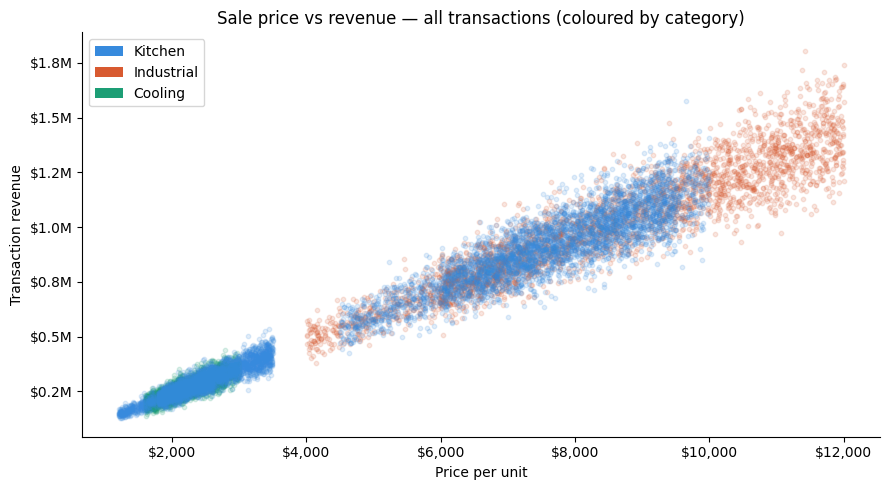

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))

cat_colors = {'Kitchen':'#378ADD','Industrial':'#D85A30','Cooling':'#1D9E75'}
for cat, grp in sales_e.groupby('category'):
    ax.scatter(grp['price'], grp['revenue'],
               alpha=0.15, s=10, color=cat_colors.get(cat,'gray'), label=cat)

ax.set_title('Sale price vs revenue — all transactions (coloured by category)')
ax.set_xlabel('Price per unit')
ax.set_ylabel('Transaction revenue')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
legend_elements = [Patch(facecolor=v, label=k) for k,v in cat_colors.items()]
ax.legend(handles=legend_elements)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


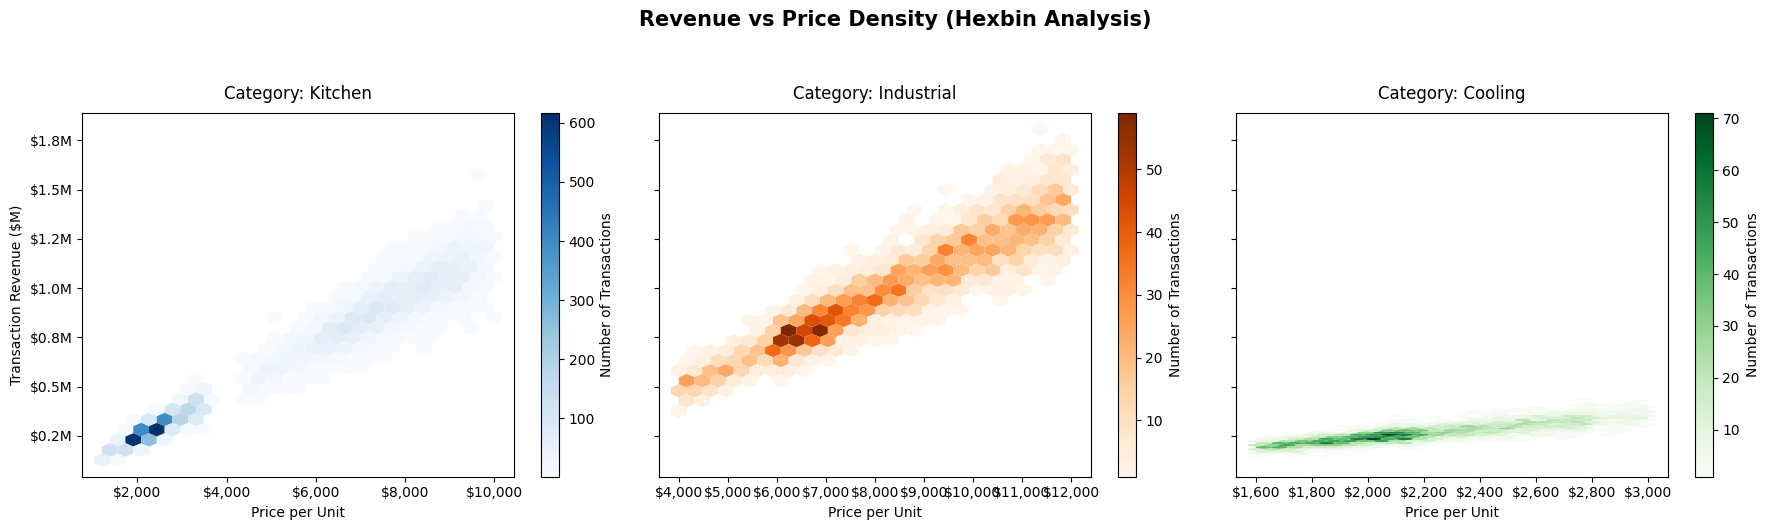

In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
plt.suptitle('Revenue vs Price Density (Hexbin Analysis)', fontsize=15, fontweight='bold', y=1.05)

categories = ['Kitchen', 'Industrial', 'Cooling']
colors = {'Kitchen': 'Blues', 'Industrial': 'Oranges', 'Cooling': 'Greens'}

for i, cat in enumerate(categories):
    subset = sales_e[sales_e['category'] == cat]

    hb = axes[i].hexbin(subset['price'], subset['revenue'],
                        gridsize=25, cmap=colors[cat], mincnt=1, edgecolors='none')

    axes[i].set_title(f'Category: {cat}', fontsize=12, pad=10)
    axes[i].set_xlabel('Price per Unit')

    axes[0].set_ylabel('Transaction Revenue ($M)')
    axes[i].xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

    cb = fig.colorbar(hb, ax=axes[i])
    cb.set_label('Number of Transactions')

plt.tight_layout()
plt.show()

### 5.5 · Monthly seasonality heatmap

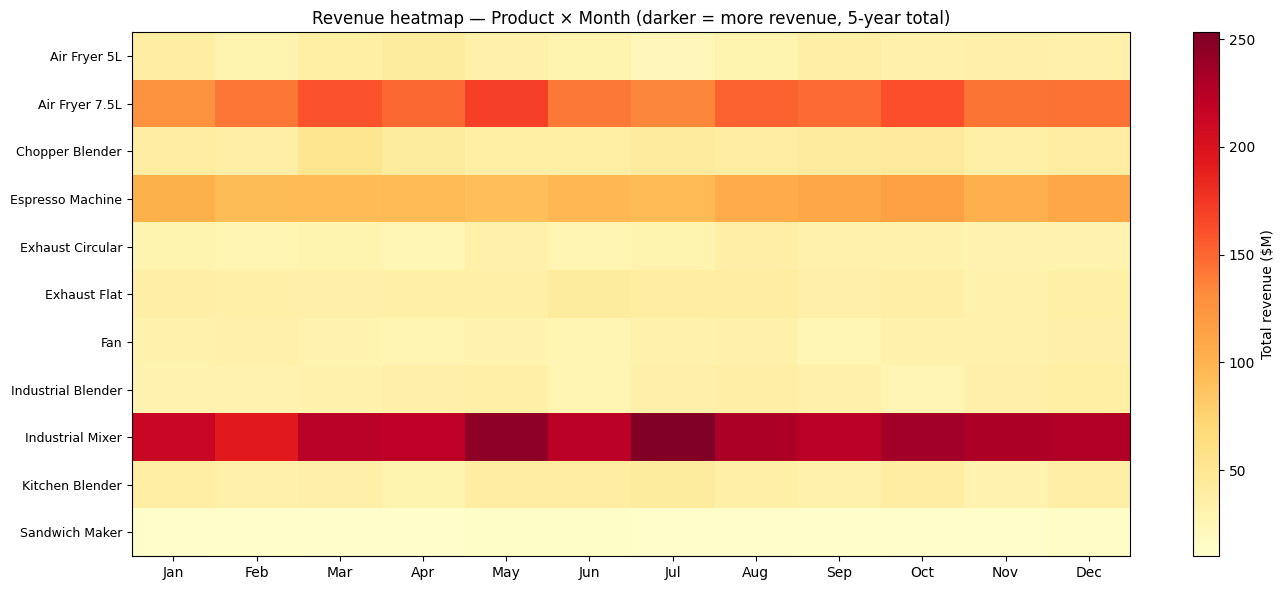

In [25]:
# Build a product × month matrix of average monthly revenue
# Extract year and month from the 'date' column
sales_e['year'] = sales_e['date'].dt.year
sales_e['month'] = sales_e['date'].dt.month

monthly_heat = (
    sales_e.groupby(['product_name','month'])['revenue']
    .sum()
    .unstack('month')
    / 1e6
)
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(monthly_heat.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(12))
ax.set_xticklabels(month_names)
ax.set_yticks(range(len(monthly_heat.index)))
ax.set_yticklabels(monthly_heat.index, fontsize=9)
plt.colorbar(im, ax=ax, label='Total revenue ($M)')
ax.set_title('Revenue heatmap — Product × Month (darker = more revenue, 5-year total)', fontsize=12)
plt.tight_layout()
plt.show()

---
## Phase 6 · Category Deep-Dives

Now we zoom into each business domain separately. Each section answers the most important business questions for that area.

### 6A · Products Analysis

**Business questions:**
- Which products generate the most revenue?
- How do the 3 categories (Kitchen, Industrial, Cooling) compare?
- Are prices consistent with contracted bounds?
- Which products have never been sold?

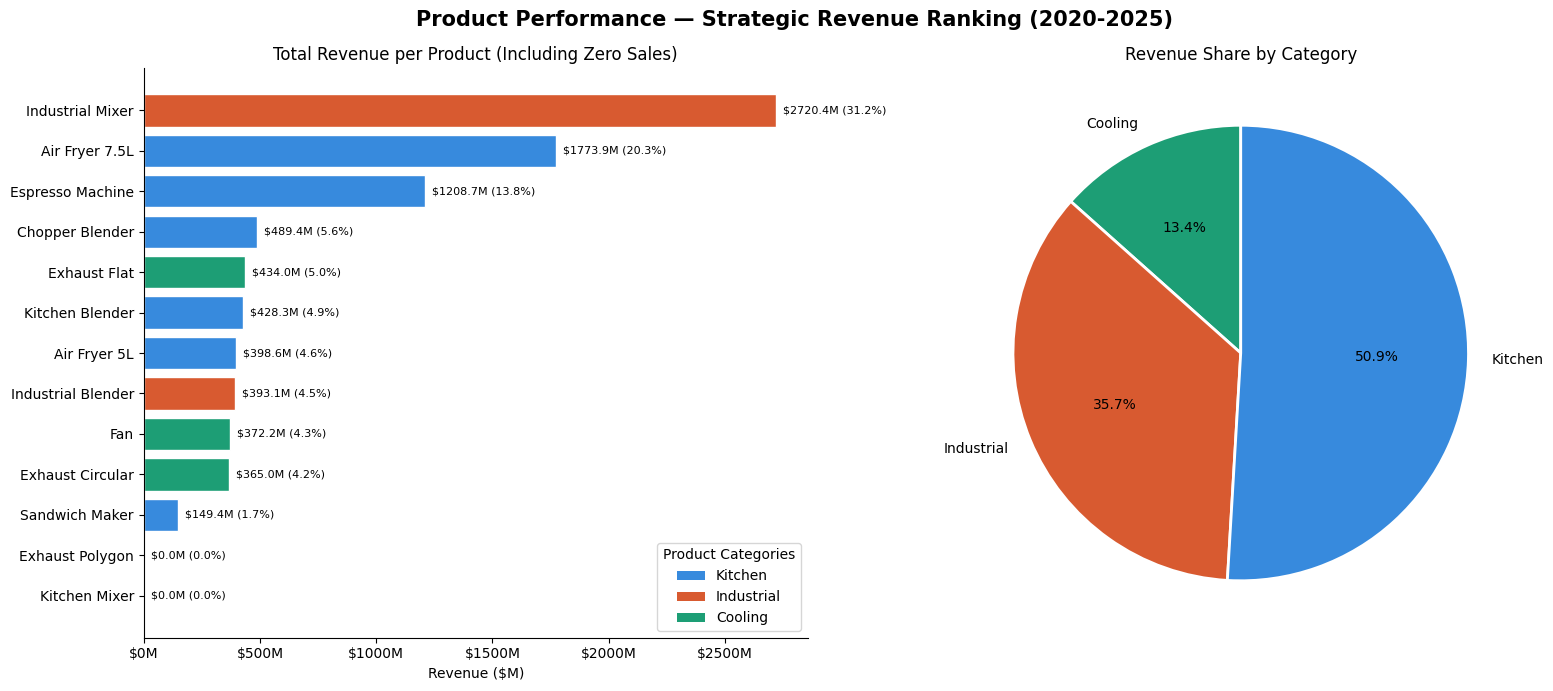


--- Final Product Performance Table ---
      product_name   category  revenue_M  revenue_pct  n_transactions
  Industrial Mixer Industrial   2,720.45        31.20        2,514.00
    Air Fryer 7.5L    Kitchen   1,773.87        20.30        1,858.00
  Espresso Machine    Kitchen   1,208.66        13.80        1,258.00
   Chopper Blender    Kitchen     489.40         5.60        1,848.00
      Exhaust Flat    Cooling     433.99         5.00        1,904.00
   Kitchen Blender    Kitchen     428.32         4.90        1,191.00
      Air Fryer 5L    Kitchen     398.55         4.60          598.00
Industrial Blender Industrial     393.14         4.50          588.00
               Fan    Cooling     372.19         4.30        1,303.00
  Exhaust Circular    Cooling     364.99         4.20        1,269.00
    Sandwich Maker    Kitchen     149.41         1.70          669.00
   Exhaust Polygon    Cooling       0.00         0.00            0.00
     Kitchen Mixer    Kitchen       0.00         

In [26]:

# 1. Aggregate sales for products that have transactions
sales_agg = sales_e.groupby('product_id').agg(
    total_revenue=('revenue', 'sum'),
    total_qty=('qty', 'sum'),
    avg_price=('price', 'mean'),
    n_transactions=('sale_id', 'count')
).reset_index()

# 2. Merge with the full products catalog (The Key Step)
# Use 'left' join to ensure products with 0 sales (like EX_POLY, MX_KIT) are included
prod_rev = products[['product_id', 'product_name', 'category']].merge(
    sales_agg, on='product_id', how='left'
)

# 3. Handle missing values for inactive/zero-sales products
# Replace NaNs with 0 to reflect zero performance
prod_rev[['total_revenue', 'total_qty', 'n_transactions']] = prod_rev[['total_revenue', 'total_qty', 'n_transactions']].fillna(0)
prod_rev['avg_price'] = prod_rev['avg_price'].fillna(0)

# 4. Final Calculations & Sorting
prod_rev = prod_rev.sort_values('total_revenue', ascending=False)
prod_rev['revenue_M'] = prod_rev['total_revenue'] / 1e6
prod_rev['revenue_pct'] = (prod_rev['total_revenue'] / prod_rev['total_revenue'].sum() * 100).round(1)

# 5. Visualization Setup
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Define category colors
cat_color_map = {'Kitchen': '#378ADD', 'Industrial': '#D85A30', 'Cooling': '#1D9E75'}
bar_colors = prod_rev['category'].map(lambda x: cat_color_map.get(x, 'gray'))

# --- Chart 1: Revenue Ranking (Bar Chart) ---
bars = axes[0].barh(prod_rev['product_name'], prod_rev['revenue_M'],
                    color=bar_colors, edgecolor='white')

# Add labels showing $M and % (Zero-sales products will now show $0.0M)
axes[0].bar_label(bars, labels=[f'${v:.1f}M ({p:.1f}%)' for v, p in
                                zip(prod_rev['revenue_M'], prod_rev['revenue_pct'])],
                  padding=5, fontsize=8)

axes[0].set_title('Total Revenue per Product (Including Zero Sales)')
axes[0].set_xlabel('Revenue ($M)')
axes[0].invert_yaxis() # Highest revenue at the top
axes[0].xaxis.set_major_formatter(mticker.FormatStrFormatter('$%0.0fM'))

# Create manual legend for categories
legend_el = [Patch(facecolor=v, label=k) for k, v in cat_color_map.items()]
axes[0].legend(handles=legend_el, loc='lower right', title="Product Categories")
axes[0].spines[['top', 'right']].set_visible(False)

# --- Chart 2: Market Share by Category (Pie Chart) ---
cat_rev = prod_rev.groupby('category')['total_revenue'].sum()
axes[1].pie(cat_rev.values, labels=cat_rev.index, autopct='%1.1f%%',
            colors=[cat_color_map.get(c, 'gray') for c in cat_rev.index],
            wedgeprops={'linewidth': 2, 'edgecolor': 'white'}, startangle=90)
axes[1].set_title('Revenue Share by Category')

plt.suptitle('Product Performance — Strategic Revenue Ranking (2020-2025)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary table for verification
print("\n--- Final Product Performance Table ---")
print(prod_rev[['product_name', 'category', 'revenue_M', 'revenue_pct', 'n_transactions']].to_string(index=False))

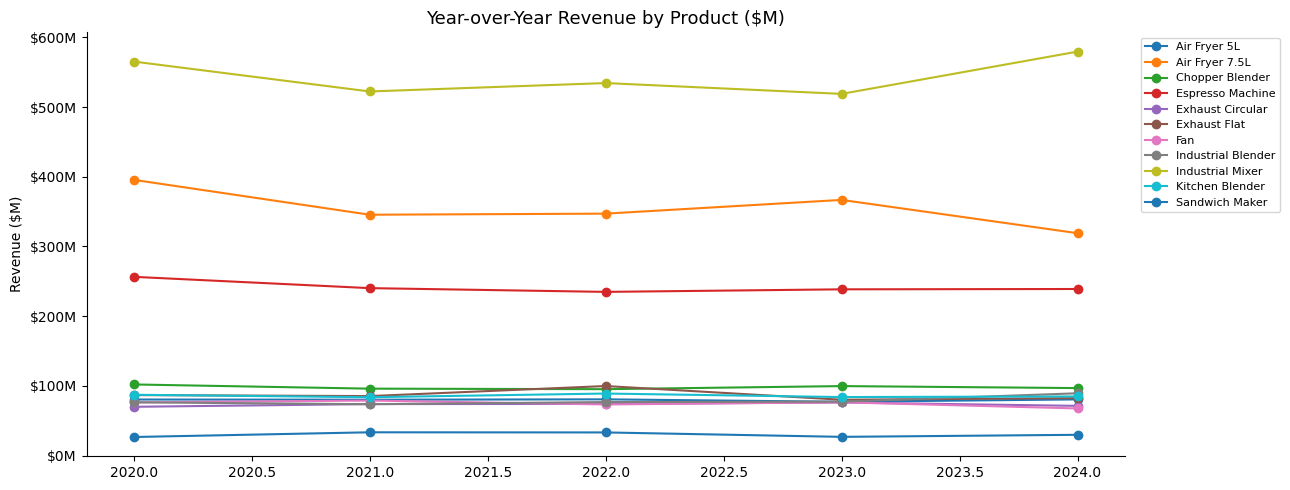


Year-over-year revenue ($M):
product_name  Air Fryer 5L  Air Fryer 7.5L  Chopper Blender  Espresso Machine  Exhaust Circular  Exhaust Flat   Fan  Industrial Blender  Industrial Mixer  Kitchen Blender  Sandwich Maker
year                                                                                                                                                                                      
2020                 80.30          395.60           101.90            256.40             69.90         86.70 76.20               76.30            565.30            87.20           26.50
2021                 80.10          345.50            95.90            240.20             73.80         85.20 78.80               73.60            522.30            83.60           33.30
2022                 80.60          347.00            95.20            234.80             74.00         99.70 73.20               76.70            534.40            88.90           33.10
2023                 77.10         

In [27]:
# ── Year-over-year revenue per product ──
yoy = (
    sales_e.groupby(['year','product_name'])['revenue']
    .sum().unstack('product_name') / 1e6
)
fig, ax = plt.subplots(figsize=(13, 5))
for col in yoy.columns:
    ax.plot(yoy.index, yoy[col], marker='o', linewidth=1.5, label=col)
ax.set_title('Year-over-Year Revenue by Product ($M)', fontsize=13)
ax.set_ylabel('Revenue ($M)')
ax.legend(bbox_to_anchor=(1.01,1), fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}M'))
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print("\nYear-over-year revenue ($M):")
print(yoy.round(1).to_string())


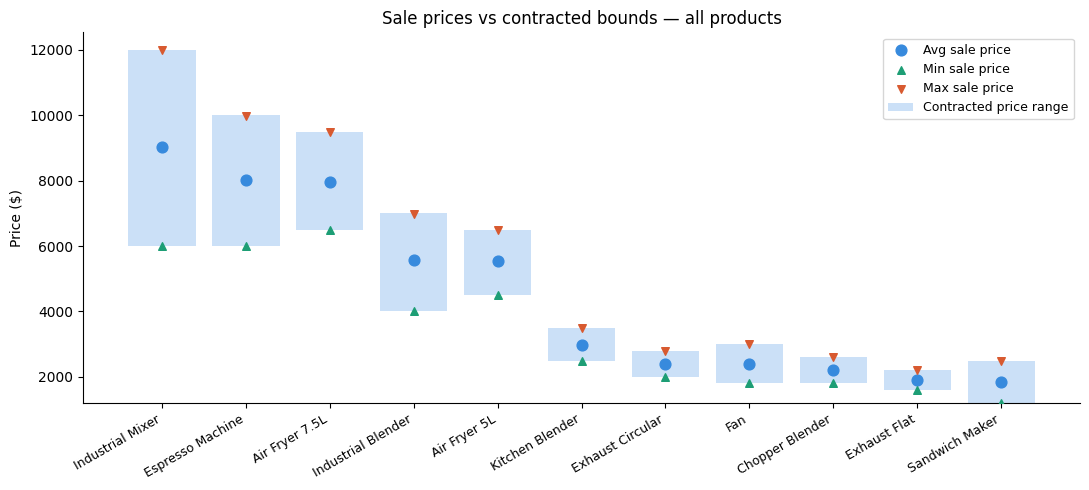

In [28]:
# ── Average price vs product price bounds ──
price_summary = (
    sales_e.groupby('product_name')['price']
    .agg(['min','mean','max'])
    .reset_index()
    .merge(products[['product_name','min_price','max_price']], on='product_name')
    .sort_values('mean', ascending=False)
)

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(price_summary))
ax.bar(x, price_summary['max_price'] - price_summary['min_price'],
       bottom=price_summary['min_price'],
       color='#B5D4F4', label='Contracted price range', alpha=0.7)
ax.scatter(x, price_summary['mean'], color='#378ADD', zorder=5,
           s=60, label='Avg sale price')
ax.scatter(x, price_summary['min'], color='#1D9E75', zorder=5,
           s=30, marker='^', label='Min sale price')
ax.scatter(x, price_summary['max'], color='#D85A30', zorder=5,
           s=30, marker='v', label='Max sale price')
ax.set_xticks(x)
ax.set_xticklabels(price_summary['product_name'], rotation=30, ha='right', fontsize=9)
ax.set_title('Sale prices vs contracted bounds — all products')
ax.set_ylabel('Price ($)')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


### 6B · Inventory Analysis

**Business questions:**
- How many days of stock does each product have?
- Which products are at risk of stockout?
- How does stock level change over time per product?

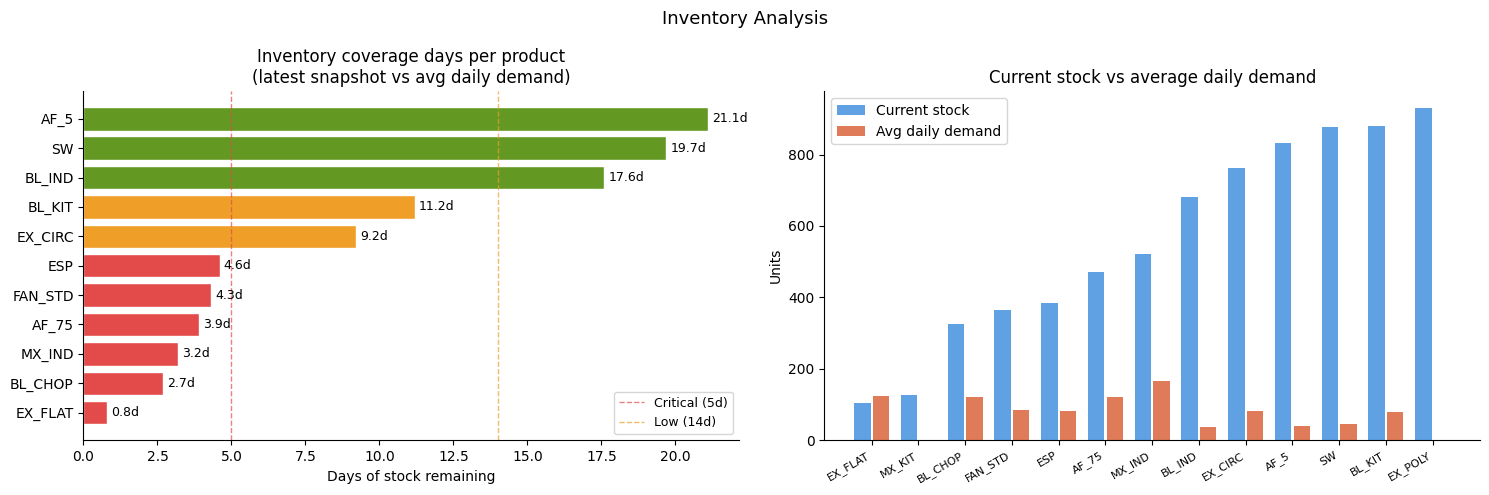


Inventory coverage table:
product_id  stock  avg_daily_demand  coverage_days risk_level
      AF_5    832             39.34          21.10  🟢 Healthy
     AF_75    471            121.91           3.90 🔴 Critical
   BL_CHOP    326            121.47           2.70 🔴 Critical
    BL_IND    680             38.55          17.60  🟢 Healthy
    BL_KIT    881             78.44          11.20      🟡 Low
       ESP    383             82.61           4.60 🔴 Critical
   EX_CIRC    763             83.18           9.20      🟡 Low
   EX_FLAT    104            125.04           0.80 🔴 Critical
   EX_POLY    931              0.00            NaN  🟢 Healthy
   FAN_STD    365             85.32           4.30 🔴 Critical
    MX_IND    522            164.84           3.20 🔴 Critical
    MX_KIT    127              0.00            NaN  🟢 Healthy
        SW    876             44.36          19.70  🟢 Healthy


In [29]:
# ── Compute inventory coverage (days of stock vs avg daily demand) ──
n_days      = sales['date'].nunique()
avg_demand  = sales.groupby('product_id')['qty'].sum() / n_days

latest_inv  = inventory.sort_values('date').groupby('product_id').last().reset_index()
latest_inv['avg_daily_demand'] = latest_inv['product_id'].map(avg_demand).fillna(0)
latest_inv['coverage_days']    = np.where(
    latest_inv['avg_daily_demand'] > 0,
    (latest_inv['stock'] / latest_inv['avg_daily_demand']).round(1),
    np.nan
)
latest_inv['risk_level'] = pd.cut(
    latest_inv['coverage_days'].fillna(999),
    bins=[-np.inf, 5, 14, np.inf],
    labels=['🔴 Critical','🟡 Low','🟢 Healthy']
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Coverage days bar chart — coloured by risk
cov_sorted = latest_inv.dropna(subset=['coverage_days']).sort_values('coverage_days')
risk_colors = {'🔴 Critical':'#E24B4A','🟡 Low':'#EF9F27','🟢 Healthy':'#639922'}
bar_colors  = cov_sorted['risk_level'].map(risk_colors)

bars = axes[0].barh(cov_sorted['product_id'], cov_sorted['coverage_days'],
                    color=bar_colors, edgecolor='white')
axes[0].bar_label(bars, labels=[f'{v:.1f}d' for v in cov_sorted['coverage_days']],
                  padding=3, fontsize=9)
axes[0].axvline(5,  color='#E24B4A', linestyle='--', linewidth=1, alpha=0.7, label='Critical (5d)')
axes[0].axvline(14, color='#EF9F27', linestyle='--', linewidth=1, alpha=0.7, label='Low (14d)')
axes[0].set_title('Inventory coverage days per product\n(latest snapshot vs avg daily demand)')
axes[0].set_xlabel('Days of stock remaining')
axes[0].legend(fontsize=9)
axes[0].spines[['top','right']].set_visible(False)

# Stock vs avg demand comparison
merged_inv = latest_inv.dropna(subset=['avg_daily_demand']).sort_values('stock')
x2 = range(len(merged_inv))
axes[1].bar([i-0.2 for i in x2], merged_inv['stock'],
            width=0.35, color='#378ADD', label='Current stock', alpha=0.8)
axes[1].bar([i+0.2 for i in x2], merged_inv['avg_daily_demand'],
            width=0.35, color='#D85A30', label='Avg daily demand', alpha=0.8)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(merged_inv['product_id'], rotation=30, ha='right', fontsize=8)
axes[1].set_title('Current stock vs average daily demand')
axes[1].set_ylabel('Units')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Inventory Analysis', fontsize=13)
plt.tight_layout()
plt.show()

print("\nInventory coverage table:")
print(latest_inv[['product_id','stock','avg_daily_demand','coverage_days','risk_level']].to_string(index=False))


### 6C · Production Analysis

**Business questions:**
- How efficient is production for each product?
- Which products have the most delays?
- Is capacity being used well?
- How does actual compare to planned output?

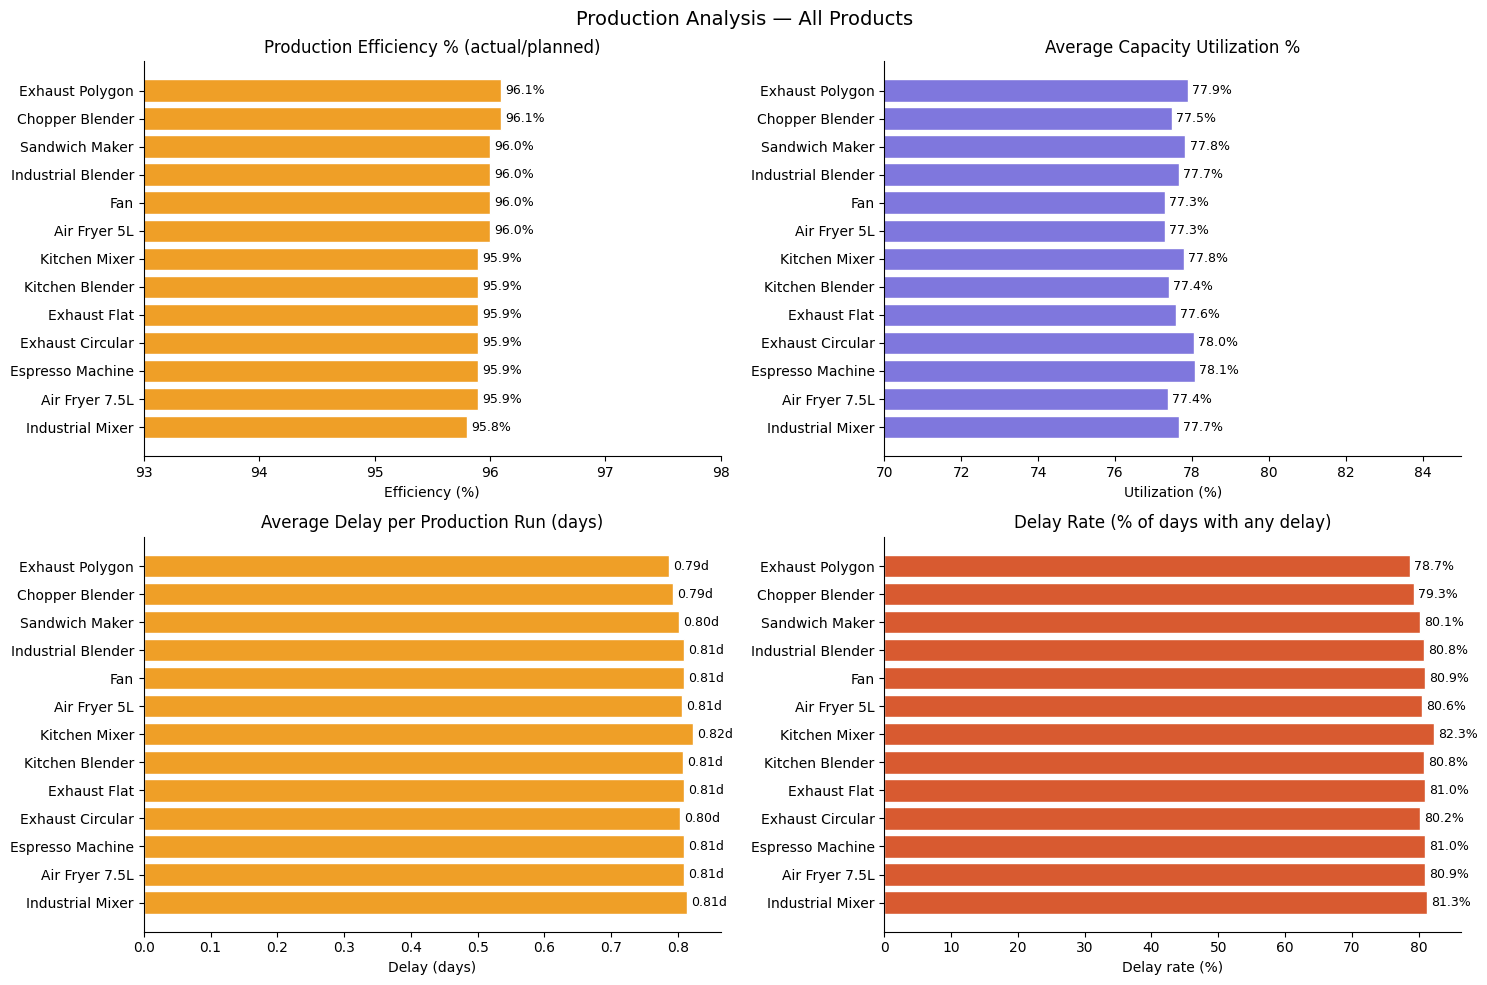

In [30]:
prod_summary = production.groupby('product_id').agg(
    total_planned  = ('planned','sum'),
    total_actual   = ('actual','sum'),
    avg_utilization= ('utilization','mean'),
    avg_delay      = ('delay','mean'),
    delay_rate     = ('delay', lambda x: (x > 0).mean())
).reset_index()
prod_summary['efficiency_pct']     = (prod_summary['total_actual'] / prod_summary['total_planned'] * 100).round(1)
prod_summary['unused_units_total'] = prod_summary['total_planned'] - prod_summary['total_actual']
prod_summary = prod_summary.sort_values('efficiency_pct')
pname_map = dict(zip(products['product_id'], products['product_name']))
prod_summary['product_name'] = prod_summary['product_id'].map(pname_map)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Efficiency %
colors_eff = ['#E24B4A' if e < 95 else '#EF9F27' if e < 97 else '#639922'
               for e in prod_summary['efficiency_pct']]
bars = axes[0,0].barh(prod_summary['product_name'], prod_summary['efficiency_pct'],
                       color=colors_eff, edgecolor='white')
axes[0,0].bar_label(bars, labels=[f'{v:.1f}%' for v in prod_summary['efficiency_pct']],
                     padding=3, fontsize=9)
axes[0,0].set_xlim(93, 98)
axes[0,0].set_title('Production Efficiency % (actual/planned)')
axes[0,0].set_xlabel('Efficiency (%)')
axes[0,0].spines[['top','right']].set_visible(False)

# Utilization
bars2 = axes[0,1].barh(prod_summary['product_name'],
                         prod_summary['avg_utilization'] * 100,
                         color='#7F77DD', edgecolor='white')
axes[0,1].bar_label(bars2, labels=[f'{v*100:.1f}%' for v in prod_summary['avg_utilization']],
                     padding=3, fontsize=9)
axes[0,1].set_xlim(70, 85)
axes[0,1].set_title('Average Capacity Utilization %')
axes[0,1].set_xlabel('Utilization (%)')
axes[0,1].spines[['top','right']].set_visible(False)

# Avg delay
bars3 = axes[1,0].barh(prod_summary['product_name'], prod_summary['avg_delay'],
                         color='#EF9F27', edgecolor='white')
axes[1,0].bar_label(bars3, labels=[f'{v:.2f}d' for v in prod_summary['avg_delay']],
                     padding=3, fontsize=9)
axes[1,0].set_title('Average Delay per Production Run (days)')
axes[1,0].set_xlabel('Delay (days)')
axes[1,0].spines[['top','right']].set_visible(False)

# Delay rate (% of days with delay > 0)
bars4 = axes[1,1].barh(prod_summary['product_name'],
                         prod_summary['delay_rate'] * 100,
                         color='#D85A30', edgecolor='white')
axes[1,1].bar_label(bars4, labels=[f'{v*100:.1f}%' for v in prod_summary['delay_rate']],
                     padding=3, fontsize=9)
axes[1,1].set_title('Delay Rate (% of days with any delay)')
axes[1,1].set_xlabel('Delay rate (%)')
axes[1,1].spines[['top','right']].set_visible(False)

plt.suptitle('Production Analysis — All Products', fontsize=14)
plt.tight_layout()
plt.show()


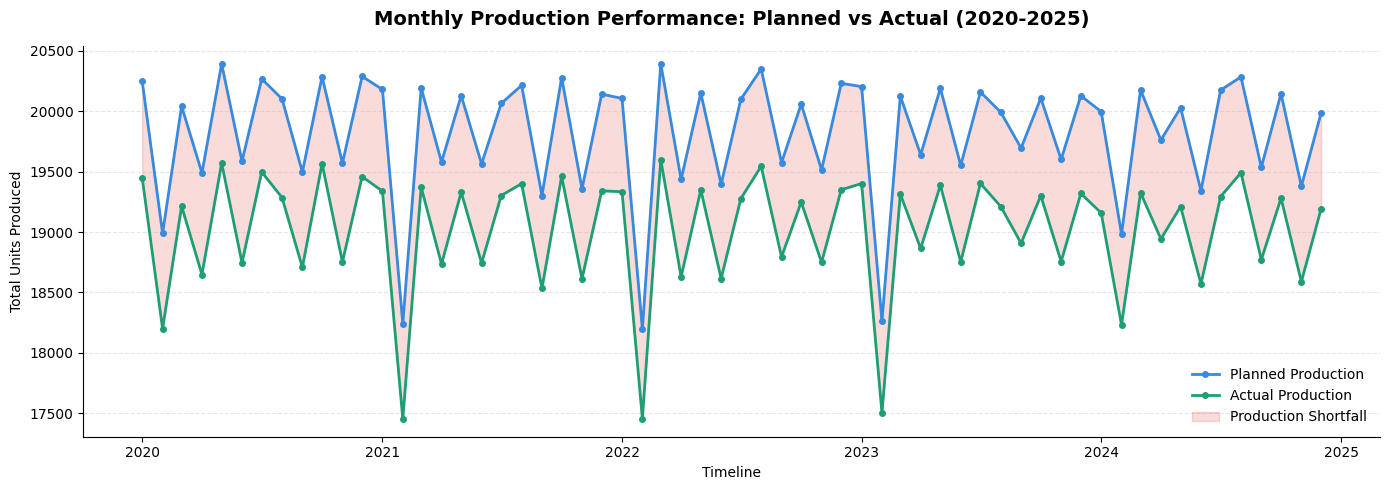

In [31]:

# 1. Resample data to Monthly to reduce noise and make trends visible
# 'MS' stands for Month Start
prod_monthly = production.set_index('date').resample('MS').agg({
    'planned': 'sum',
    'actual': 'sum'
}).reset_index()

# 2. Plotting the cleaned-up version
fig, ax = plt.subplots(figsize=(14, 5))

# Plot Planned line
ax.plot(prod_monthly['date'], prod_monthly['planned'], color='#378ADD',
        linewidth=2, label='Planned Production', marker='o', markersize=4)

# Plot Actual line
ax.plot(prod_monthly['date'], prod_monthly['actual'], color='#1D9E75',
        linewidth=2, label='Actual Production', marker='o', markersize=4)

# Highlight the Shortfall (The gap between them)
ax.fill_between(prod_monthly['date'], prod_monthly['actual'],
                prod_monthly['planned'], alpha=0.2, color='#E24B4A',
                label='Production Shortfall')

# 3. Aesthetics & Formatting
ax.set_title('Monthly Production Performance: Planned vs Actual (2020-2025)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Total Units Produced')
ax.set_xlabel('Timeline')

# Show only the necessary spines
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.3) # Add light grid for better reading
ax.legend(loc='lower right', frameon=False)

plt.tight_layout()
plt.show()

### 6D · Suppliers Analysis

**Business questions:**
- Which suppliers are most critical (highest cost contribution)?
- Who has the best reliability vs lead time tradeoff?
- Which region supplies the most materials?
- Are low-reliability suppliers carrying high-cost materials?

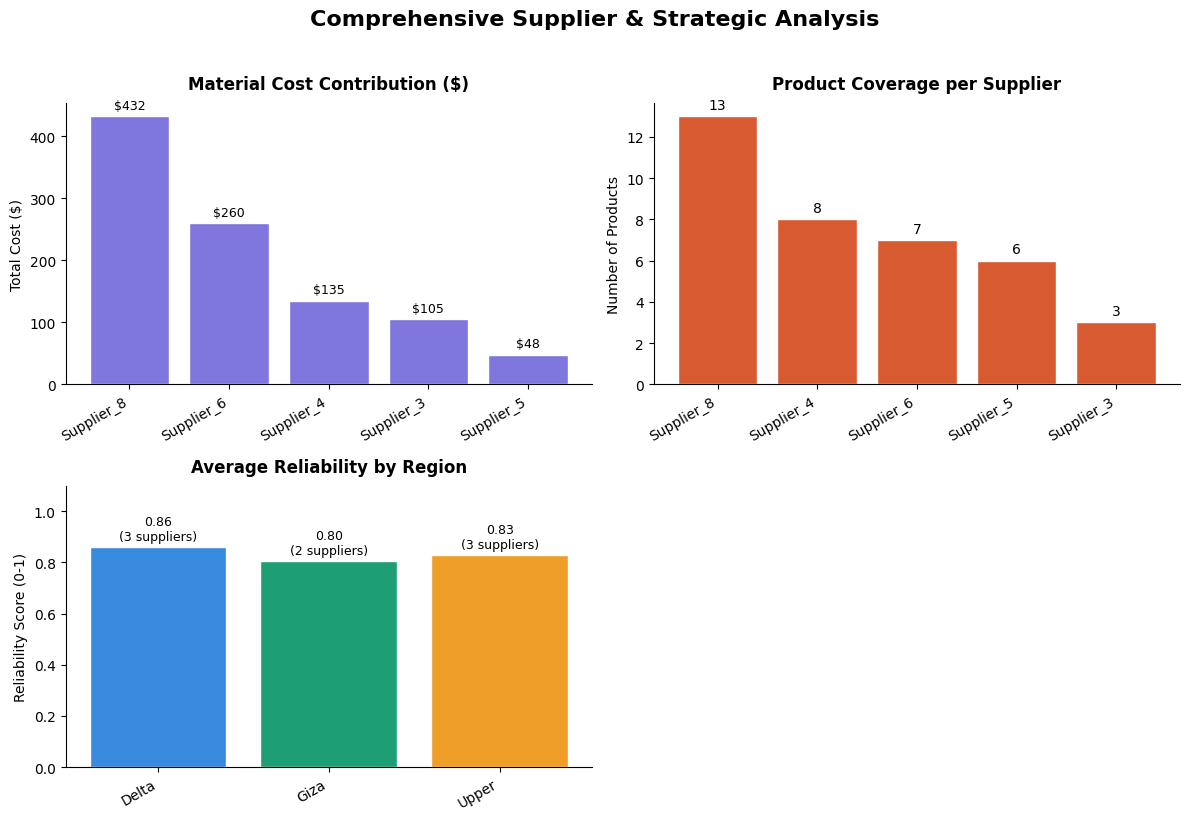

In [32]:

# 1. Prepare and Combine Data
# Merge BOM with Materials and Suppliers to get a full view
bom_full = bom.merge(raw_mat, on='material_id').merge(suppliers, on='supplier_id')
bom_full['line_cost'] = bom_full['qty'] * bom_full['unit_cost']

# Supplier financial contribution analysis
sup_analysis = (
    bom_full.groupby(['supplier_id', 'supplier_name', 'region', 'reliability', 'lead_time_days'])
    ['line_cost'].sum().reset_index()
    .rename(columns={'line_cost': 'total_cost_contrib'})
    .sort_values('total_cost_contrib', ascending=False)
)

# Region-level performance metrics
region_agg = suppliers.groupby('region').agg(
    avg_reliability=('reliability', 'mean'),
    n_suppliers=('supplier_id', 'count')
).reset_index()

# 2. Plotting Layout
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plt.suptitle('Comprehensive Supplier & Strategic Analysis', fontsize=16, fontweight='bold', y=1.02)

# Helper function for consistent styling
def style_ax(ax, title, ylabel):
    ax.set_title(title, fontsize=12, pad=10, fontweight='semibold')
    ax.set_ylabel(ylabel)
    ax.spines[['top', 'right']].set_visible(False)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# --- Chart 0,0: Financial Contribution per Supplier ---
bars1 = axes[0,0].bar(sup_analysis['supplier_name'], sup_analysis['total_cost_contrib'], color='#7F77DD', edgecolor='white')
axes[0,0].bar_label(bars1, labels=[f'${v:,.0f}' for v in sup_analysis['total_cost_contrib']], padding=3, fontsize=9)
style_ax(axes[0,0], 'Material Cost Contribution ($)', 'Total Cost ($)')

# --- Chart 0,1: Supplier Reach (Products Served) ---
sup_product_count = (
    bom_full.groupby('supplier_name')['product_id'].nunique()
    .reset_index().rename(columns={'product_id': 'num_products'})
    .sort_values('num_products', ascending=False)
)
bars2 = axes[0,1].bar(sup_product_count['supplier_name'], sup_product_count['num_products'], color='#D85A30', edgecolor='white')
axes[0,1].bar_label(bars2, padding=3)
style_ax(axes[0,1], 'Product Coverage per Supplier', 'Number of Products')

# --- Chart 1,0: Regional Reliability ---
bars3 = axes[1,0].bar(region_agg['region'], region_agg['avg_reliability'], color=['#378ADD', '#1D9E75', '#EF9F27'], edgecolor='white')
# Adding count of suppliers in brackets for context
labels_reg = [f"{row['avg_reliability']:.2f}\n({row['n_suppliers']} suppliers)" for _, row in region_agg.iterrows()]
axes[1,0].bar_label(bars3, labels=labels_reg, padding=3, fontsize=9)
axes[1,0].set_ylim(0, 1.1)
style_ax(axes[1,0], 'Average Reliability by Region', 'Reliability Score (0-1)')

# --- Chart 1,1: Empty/Bonus Chart (Removing unused subplot) ---
# Can be used for extra metrics or just hidden
axes[1,1].axis('off')

plt.tight_layout()
plt.show()

### 6E · Raw Materials Analysis

**Business questions:**
- Which materials are most expensive?
- Which materials are used across the most products?
- What is the total material cost per product (BOM cost)?
- Which materials come from risky suppliers?

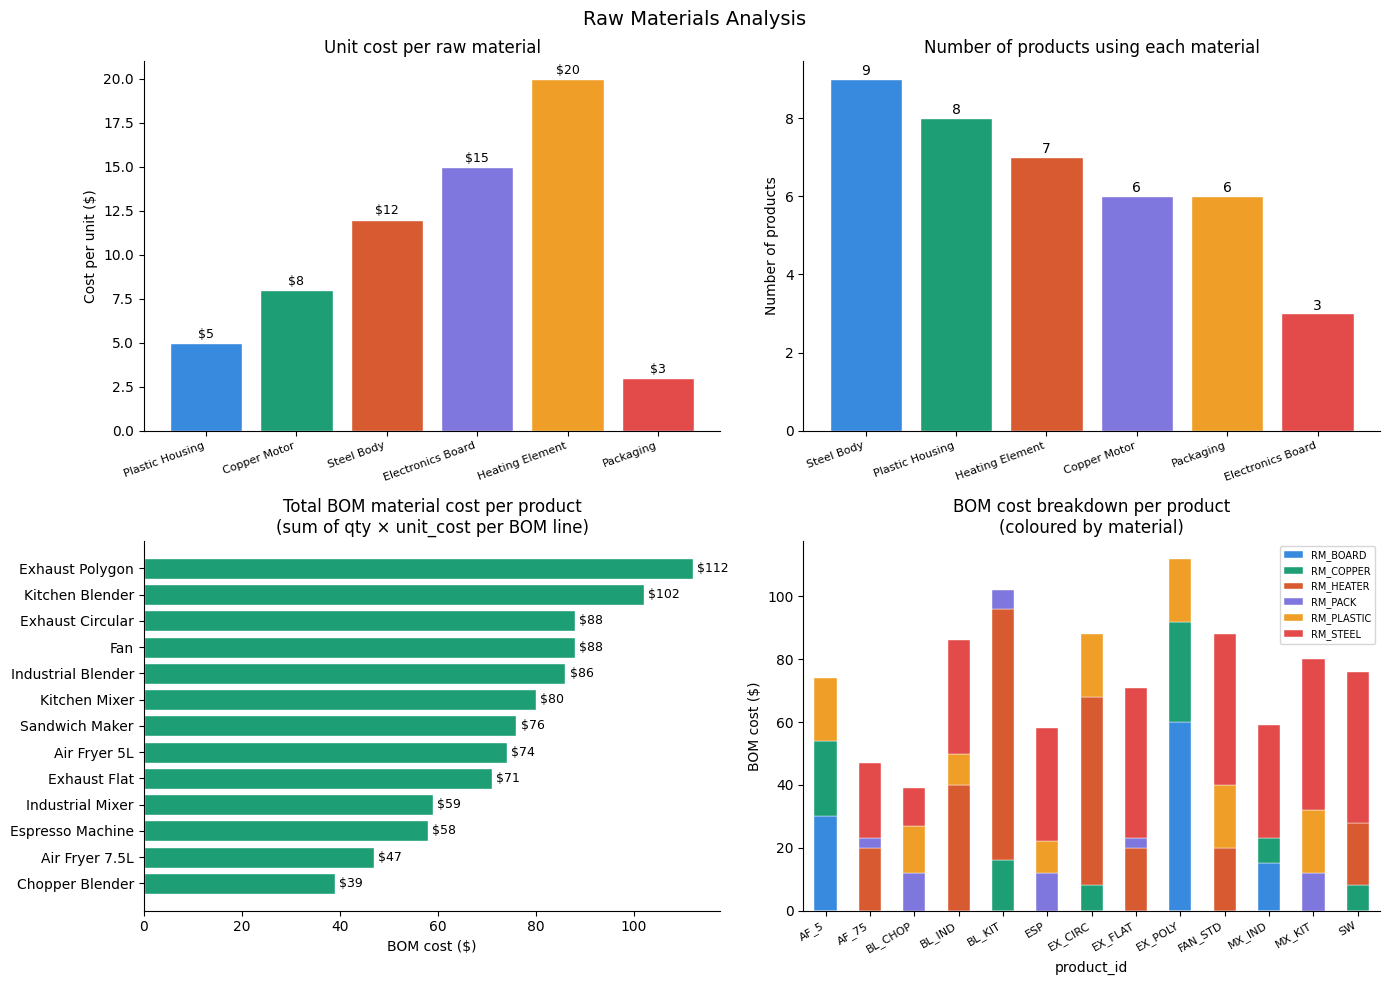


BOM cost per product:
      product_name  total_bom_cost
   Exhaust Polygon             112
   Kitchen Blender             102
  Exhaust Circular              88
               Fan              88
Industrial Blender              86
     Kitchen Mixer              80
    Sandwich Maker              76
      Air Fryer 5L              74
      Exhaust Flat              71
  Industrial Mixer              59
  Espresso Machine              58
    Air Fryer 7.5L              47
   Chopper Blender              39


In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

mat_colors = ['#378ADD','#1D9E75','#D85A30','#7F77DD','#EF9F27','#E24B4A']

# Unit cost per material
axes[0,0].bar(raw_mat['material_name'], raw_mat['unit_cost'],
              color=mat_colors, edgecolor='white')
for i, (_, row) in enumerate(raw_mat.iterrows()):
    axes[0,0].text(i, row['unit_cost'] + 0.3, f"${row['unit_cost']}",
                   ha='center', fontsize=9)
axes[0,0].set_title('Unit cost per raw material')
axes[0,0].set_ylabel('Cost per unit ($)')
plt.setp(axes[0,0].get_xticklabels(), rotation=20, ha='right', fontsize=8)
axes[0,0].spines[['top','right']].set_visible(False)

# How many products use each material
mat_usage = bom.groupby('material_id')['product_id'].nunique().reset_index()
mat_usage = mat_usage.merge(raw_mat[['material_id','material_name']], on='material_id')
mat_usage = mat_usage.sort_values('product_id', ascending=False)
axes[0,1].bar(mat_usage['material_name'], mat_usage['product_id'],
              color=mat_colors, edgecolor='white')
axes[0,1].set_title('Number of products using each material')
axes[0,1].set_ylabel('Number of products')
for i, (_, row) in enumerate(mat_usage.iterrows()):
    axes[0,1].text(i, row['product_id'] + 0.1, str(row['product_id']),
                   ha='center', fontsize=10)
plt.setp(axes[0,1].get_xticklabels(), rotation=20, ha='right', fontsize=8)
axes[0,1].spines[['top','right']].set_visible(False)

# Total BOM cost per product
bom_cost = bom.merge(raw_mat[['material_id','unit_cost']], on='material_id')
bom_cost['line_cost'] = bom_cost['qty'] * bom_cost['unit_cost']
prod_bom_cost = (
    bom_cost.groupby('product_id')['line_cost'].sum()
    .reset_index().rename(columns={'line_cost':'total_bom_cost'})
    .sort_values('total_bom_cost', ascending=False)
)
prod_bom_cost['product_name'] = prod_bom_cost['product_id'].map(pname_map)
axes[1,0].barh(prod_bom_cost['product_name'], prod_bom_cost['total_bom_cost'],
               color='#1D9E75', edgecolor='white')
axes[1,0].bar_label(axes[1,0].containers[0],
                     labels=[f'${v}' for v in prod_bom_cost['total_bom_cost']],
                     padding=3, fontsize=9)
axes[1,0].set_title('Total BOM material cost per product\n(sum of qty × unit_cost per BOM line)')
axes[1,0].set_xlabel('BOM cost ($)')
axes[1,0].invert_yaxis()
axes[1,0].spines[['top','right']].set_visible(False)

# Material cost breakdown (stacked) for each product
bom_stacked = (
    bom_cost.groupby(['product_id','material_id'])['line_cost']
    .sum().unstack(fill_value=0)
)
bom_stacked.plot(kind='bar', stacked=True, ax=axes[1,1],
                 color=mat_colors[:len(bom_stacked.columns)], edgecolor='white', linewidth=0.3)
axes[1,1].set_title('BOM cost breakdown per product\n(coloured by material)')
axes[1,1].set_ylabel('BOM cost ($)')
axes[1,1].set_xticklabels(bom_stacked.index, rotation=30, ha='right', fontsize=8)
axes[1,1].legend(fontsize=7, loc='upper right')
axes[1,1].spines[['top','right']].set_visible(False)

plt.suptitle('Raw Materials Analysis', fontsize=14)
plt.tight_layout()
plt.show()

print("\nBOM cost per product:")
print(prod_bom_cost[['product_name','total_bom_cost']].to_string(index=False))


---
## Phase 7 · Data Cleaning

Based on the quality checks in Phase 3, we now fix everything that needs fixing and document every change.

In [34]:
# ── 7.1 Flag inactive products ────────────────────────────────────
# EX_POLY and MX_KIT appear in the products catalog but have zero sales
# We add a flag so dashboards and models can filter them out correctly
sold_pids = set(sales['product_id'].unique())
products['is_active'] = products['product_id'].isin(sold_pids)

print("Product active flags:")
print(products[['product_id','product_name','is_active']].to_string(index=False))

Product active flags:
product_id       product_name  is_active
   FAN_STD                Fan       True
   EX_FLAT       Exhaust Flat       True
   EX_POLY    Exhaust Polygon      False
   EX_CIRC   Exhaust Circular       True
      AF_5       Air Fryer 5L       True
     AF_75     Air Fryer 7.5L       True
   BL_CHOP    Chopper Blender       True
    BL_KIT    Kitchen Blender       True
    BL_IND Industrial Blender       True
       ESP   Espresso Machine       True
        SW     Sandwich Maker       True
    MX_KIT      Kitchen Mixer      False
    MX_IND   Industrial Mixer       True


In [35]:
# ── 7.3 Standardise column names to snake_case ────────────────────
# snake_case means: all lowercase, spaces replaced by underscores
# This avoids errors when accessing columns by name in code

def to_snake(df):
    df.columns = [c.strip().lower().replace(' ','_') for c in df.columns]
    return df

for name in list(ALL_TABLES.keys()):
    ALL_TABLES[name] = to_snake(ALL_TABLES[name])

# Re-assign to variables after rename
contracts = ALL_TABLES['contracts'];  products  = ALL_TABLES['products']
sales     = ALL_TABLES['sales'];      inventory = ALL_TABLES['inventory']
production= ALL_TABLES['production']; bom       = ALL_TABLES['bom']
raw_mat   = ALL_TABLES['raw_materials']; suppliers = ALL_TABLES['suppliers']

print("Column names standardised to snake_case ✅")
print("Sample columns — sales:", sales.columns.tolist())


Column names standardised to snake_case ✅
Sample columns — sales: ['sale_id', 'date', 'product_id', 'contract_id', 'qty', 'price', 'revenue']


In [36]:
# ── 7.4 Convert utilization from decimal to percent ───────────────

# Easier to read: 0.77 → 77.0%  (we keep both versions)

production['utilization_pct'] = (production['utilization'] * 100).round(2)



# ── 7.5 Add contract duration column ──────────────────────────────

contracts['duration_days'] = (contracts['end'] - contracts['start']).dt.days



print("Cleaning complete. Added columns:")

print("  production.utilization_pct  (0–100 scale)")

print("  contracts.duration_days     (contract length in days)")

print(f"\nFinal row counts:")

for name, df in ALL_TABLES.items():

    print(f"  {name:20s}: {len(df):,} rows")

Cleaning complete. Added columns:
  production.utilization_pct  (0–100 scale)
  contracts.duration_days     (contract length in days)

Final row counts:
  contracts           : 24 rows
  products            : 13 rows
  sales               : 15,000 rows
  inventory           : 23,751 rows
  production          : 23,751 rows
  bom                 : 39 rows
  raw_materials       : 6 rows
  suppliers           : 8 rows


---
## Phase 8 · Data Integration

We join tables together to create richer analytical datasets. Think of each join as answering the question: *'what else do we know about this row?'*

### 8.1 · Enriched sales table

In [37]:
# Add product attributes (name, category, type) to every sale row
# Add contract info (monthly_qty, contracted price)
sales_enriched = (
    sales
    .merge(products[['product_id','product_name','category','type',
                      'min_price','max_price','is_active']],
           on='product_id', how='left')
    .merge(contracts[['contract_id','client','monthly_qty',
                       'price','duration_days']].rename(
               columns={'price':'contracted_price','monthly_qty':'contracted_monthly_qty'}),
           on='contract_id', how='left')
)

# Useful time columns
sales_enriched['year']    = sales_enriched['date'].dt.year
sales_enriched['month']   = sales_enriched['date'].dt.month
sales_enriched['quarter'] = sales_enriched['date'].dt.quarter
sales_enriched['week']    = sales_enriched['date'].dt.isocalendar().week.astype(int)
sales_enriched['ym']      = sales_enriched['date'].dt.to_period('M').astype(str)
sales_enriched['weekday'] = sales_enriched['date'].dt.day_name()

print(f"sales_enriched: {sales_enriched.shape}")
print(sales_enriched.head(3).to_string())


sales_enriched: (15000, 23)
   sale_id       date product_id contract_id  qty  price  revenue      product_name    category      type  min_price  max_price  is_active                client  contracted_monthly_qty  contracted_price  duration_days  year  month  quarter  week       ym    weekday
0        0 2020-08-07     BL_KIT       CON_9  100   3373   337300   Kitchen Blender     Kitchen   Blender       2500       3500       True   Industrial_Client_9                     116              2750           1826  2020      8        3    32  2020-08     Friday
1        1 2023-11-15    FAN_STD       CON_7  130   2331   303030               Fan     Cooling  Standard       1800       3000       True   Industrial_Client_7                     455              2528           1826  2023     11        4    46  2023-11  Wednesday
2        2 2021-12-23     MX_IND      CON_22  102  10589  1080078  Industrial Mixer  Industrial     Mixer       6000      12000       True  Industrial_Client_22              

### 8.2 · Enriched inventory table

In [38]:
inventory_enriched = inventory.merge(
    products[['product_id','product_name','category','type','is_active']],
    on='product_id', how='left'
)

# Add avg daily demand for each product
avg_daily = sales.groupby('product_id')['qty'].sum() / sales['date'].nunique()
inventory_enriched['avg_daily_demand'] = inventory_enriched['product_id'].map(avg_daily).fillna(0)
inventory_enriched['coverage_days']    = np.where(
    inventory_enriched['avg_daily_demand'] > 0,
    (inventory_enriched['stock'] / inventory_enriched['avg_daily_demand']).round(2),
    np.nan
)
inventory_enriched['stock_status'] = pd.cut(
    inventory_enriched['coverage_days'].fillna(999),
    bins=[-np.inf, 5, 14, np.inf],
    labels=['Critical','Low','Healthy']
)

print(f"inventory_enriched: {inventory_enriched.shape}")
print(inventory_enriched.head(3).to_string())


inventory_enriched: (23751, 10)
        date product_id  stock     product_name category      type  is_active  avg_daily_demand  coverage_days stock_status
0 2020-01-01    FAN_STD    204              Fan  Cooling  Standard       True             85.32           2.39     Critical
1 2020-01-01    EX_FLAT    330     Exhaust Flat  Cooling   Exhaust       True            125.04           2.64     Critical
2 2020-01-01    EX_POLY    570  Exhaust Polygon  Cooling   Exhaust      False              0.00            NaN      Healthy


### 8.3 · Enriched production table

In [39]:
production_enriched = production.merge(
    products[['product_id','product_name','category','is_active']],
    on='product_id', how='left'
)
production_enriched['efficiency_pct']  = (production_enriched['actual'] / production_enriched['planned'] * 100).round(2)
production_enriched['unused_capacity'] = production_enriched['planned'] - production_enriched['actual']
production_enriched['is_delayed']      = production_enriched['delay'] > 0

print(f"production_enriched: {production_enriched.shape}")
print(production_enriched.head(3).to_string())


production_enriched: (23751, 13)
        date product_id  planned  actual  utilization  delay  utilization_pct     product_name category  is_active  efficiency_pct  unused_capacity  is_delayed
0 2020-01-01    FAN_STD       48      46         0.67      1            67.00              Fan  Cooling       True           95.83                2        True
1 2020-01-01    EX_FLAT       55      53         0.63      1            63.00     Exhaust Flat  Cooling       True           96.36                2        True
2 2020-01-01    EX_POLY       47      47         0.82      0            82.00  Exhaust Polygon  Cooling      False          100.00                0       False


### 8.4 · Full supply chain table (BOM + materials + suppliers)

In [40]:
supply_chain = (
    bom
    .merge(raw_mat, on='material_id')
    .merge(suppliers, on='supplier_id')
    .merge(products[['product_id','product_name','category']], on='product_id', how='left')
)
supply_chain['line_cost'] = supply_chain['qty'] * supply_chain['unit_cost']

# Product-level material cost summary
product_mat_cost = (
    supply_chain.groupby('product_id')['line_cost']
    .sum().reset_index()
    .rename(columns={'line_cost':'total_material_cost'})
)

print(f"supply_chain: {supply_chain.shape}")
print(supply_chain.head(5).to_string())
print("\nMaterial cost per product:")
print(product_mat_cost.to_string(index=False))


supply_chain: (39, 13)
  product_id material_id  qty    material_name  unit_cost supplier_id supplier_name region  reliability  lead_time_days  product_name category  line_cost
0    FAN_STD  RM_PLASTIC    4  Plastic Housing          5       SUP_4    Supplier_4   Giza         0.87               7           Fan  Cooling         20
1    FAN_STD    RM_STEEL    4       Steel Body         12       SUP_8    Supplier_8  Delta         0.94               9           Fan  Cooling         48
2    FAN_STD   RM_HEATER    1  Heating Element         20       SUP_6    Supplier_6  Delta         0.74              10           Fan  Cooling         20
3    EX_FLAT    RM_STEEL    4       Steel Body         12       SUP_8    Supplier_8  Delta         0.94               9  Exhaust Flat  Cooling         48
4    EX_FLAT     RM_PACK    1        Packaging          3       SUP_5    Supplier_5   Giza         0.74               9  Exhaust Flat  Cooling          3

Material cost per product:
product_id  total_materia

---
## Phase 9 · Feature Engineering

Feature engineering means creating *new columns* from existing ones. These new features make patterns easier for dashboards to display and for models to learn.

### 9.1 · Monthly sales aggregation

In [41]:
monthly_sales = (
    sales_enriched
    .groupby(['year','month','ym','product_id','product_name','category'])
    .agg(
        monthly_qty     = ('qty',     'sum'),
        monthly_revenue = ('revenue', 'sum'),
        avg_price       = ('price',   'mean'),
        n_transactions  = ('sale_id', 'count')
    )
    .reset_index()
)
monthly_sales['avg_price'] = monthly_sales['avg_price'].round(0)
print(f"monthly_sales: {monthly_sales.shape}")
print(monthly_sales.tail(6).to_string(index=False))


monthly_sales: (660, 10)
 year  month      ym product_id     product_name   category  monthly_qty  monthly_revenue  avg_price  n_transactions
 2024     12 2024-12        ESP Espresso Machine    Kitchen         2734         22447737   8,209.00              23
 2024     12 2024-12    EX_CIRC Exhaust Circular    Cooling         2734          6441218   2,352.00              23
 2024     12 2024-12    EX_FLAT     Exhaust Flat    Cooling         2401          4612001   1,922.00              20
 2024     12 2024-12    FAN_STD              Fan    Cooling         2191          5301414   2,430.00              18
 2024     12 2024-12     MX_IND Industrial Mixer Industrial         5278         48190999   9,132.00              44
 2024     12 2024-12         SW   Sandwich Maker    Kitchen         1982          3866066   1,950.00              16


### 9.2 · Gross margin estimate

In [42]:
# Gross margin = revenue - material cost
# This is an estimate — real margin would include labour, overhead, etc.
sales_enriched = sales_enriched.merge(product_mat_cost, on='product_id', how='left')
sales_enriched['material_cost_total'] = sales_enriched['qty'] * sales_enriched['total_material_cost']
sales_enriched['gross_margin']        = sales_enriched['revenue'] - sales_enriched['material_cost_total']
sales_enriched['margin_pct']          = (sales_enriched['gross_margin'] / sales_enriched['revenue'] * 100).round(2)

margin_summary = (
    sales_enriched.groupby('product_name')[['revenue','gross_margin','margin_pct']]
    .mean().sort_values('margin_pct', ascending=False)
)
print("Average gross margin per product:")
print(margin_summary.round(2).to_string())


Average gross margin per product:
                        revenue  gross_margin  margin_pct
product_name                                             
Air Fryer 7.5L       954,722.19    949,087.89       99.40
Industrial Mixer   1,082,118.39  1,075,050.71       99.32
Espresso Machine     960,780.38    953,821.85       99.26
Air Fryer 5L         666,478.99    657,585.13       98.65
Industrial Blender   668,612.29    658,310.86       98.42
Chopper Blender      264,829.34    260,146.03       98.21
Kitchen Blender      359,631.92    347,357.83       96.55
Exhaust Circular     287,618.32    277,079.68       96.30
Fan                  285,638.64    275,111.19       96.24
Exhaust Flat         227,933.45    219,414.38       96.23
Sandwich Maker       223,334.24    214,127.22       95.69


### 9.3 · Contract compliance — actual vs contracted monthly demand

---



In [43]:
demand_compliance = (
    sales_enriched
    .groupby(['ym','product_id'])
    .agg(
        actual_qty     = ('qty',                  'sum'),
        contracted_qty = ('contracted_monthly_qty','first')
    )
    .reset_index()
)
demand_compliance['compliance_pct'] = (
    demand_compliance['actual_qty'] / demand_compliance['contracted_qty'] * 100
).round(1)

print("Demand compliance sample (first 10 rows):")
print(demand_compliance.head(10).to_string(index=False))


Demand compliance sample (first 10 rows):
     ym product_id  actual_qty  contracted_qty  compliance_pct
2020-01       AF_5        1461             152          961.20
2020-01      AF_75        3510             160        2,193.80
2020-01    BL_CHOP        2817             454          620.50
2020-01     BL_IND         811             131          619.10
2020-01     BL_KIT        2121             265          800.40
2020-01        ESP        3296             333          989.80
2020-01    EX_CIRC        2382             308          773.40
2020-01    EX_FLAT        3128             432          724.10
2020-01    FAN_STD        2659             455          584.40
2020-01     MX_IND        5718             131        4,364.90


In [44]:
print("Available DataFrame Names:")
print("--------------------------")

print("Original Tables (from ALL_TABLES):")
for name in ALL_TABLES.keys():
    print(f"- {name}")

print("\nEnriched and Aggregated Tables:")
print("- sales_enriched")
print("- inventory_enriched")
print("- production_enriched")
print("- supply_chain")
print("- monthly_sales")
print("- demand_compliance")
print("- product_mat_cost")
print("- margin_summary")

Available DataFrame Names:
--------------------------
Original Tables (from ALL_TABLES):
- contracts
- products
- sales
- inventory
- production
- bom
- raw_materials
- suppliers

Enriched and Aggregated Tables:
- sales_enriched
- inventory_enriched
- production_enriched
- supply_chain
- monthly_sales
- demand_compliance
- product_mat_cost
- margin_summary


In [45]:
print("Column names for all tables:")
print("------------------------------")

# Original tables
for name, df in ALL_TABLES.items():
    print(f"\nTABLE: {name.upper()}")
    print(df.columns.tolist())

# Enriched and aggregated tables
print("\nTABLE: SALES_ENRICHED")
print(sales_enriched.columns.tolist())

print("\nTABLE: INVENTORY_ENRICHED")
print(inventory_enriched.columns.tolist())

print("\nTABLE: PRODUCTION_ENRICHED")
print(production_enriched.columns.tolist())

print("\nTABLE: SUPPLY_CHAIN")
print(supply_chain.columns.tolist())

print("\nTABLE: MONTHLY_SALES")
print(monthly_sales.columns.tolist())

print("\nTABLE: DEMAND_COMPLIANCE")
print(demand_compliance.columns.tolist())

print("\nTABLE: PRODUCT_MAT_COST")
print(product_mat_cost.columns.tolist())

print("\nTABLE: MARGIN_SUMMARY")
print(margin_summary.columns.tolist())



Column names for all tables:
------------------------------

TABLE: CONTRACTS
['contract_id', 'client', 'product_id', 'start', 'end', 'monthly_qty', 'price', 'duration_days']

TABLE: PRODUCTS
['product_id', 'product_name', 'category', 'type', 'size', 'min_price', 'max_price', 'is_active']

TABLE: SALES
['sale_id', 'date', 'product_id', 'contract_id', 'qty', 'price', 'revenue']

TABLE: INVENTORY
['date', 'product_id', 'stock']

TABLE: PRODUCTION
['date', 'product_id', 'planned', 'actual', 'utilization', 'delay', 'utilization_pct']

TABLE: BOM
['product_id', 'material_id', 'qty']

TABLE: RAW_MATERIALS
['material_id', 'material_name', 'unit_cost', 'supplier_id']

TABLE: SUPPLIERS
['supplier_id', 'supplier_name', 'region', 'reliability', 'lead_time_days']

TABLE: SALES_ENRICHED
['sale_id', 'date', 'product_id', 'contract_id', 'qty', 'price', 'revenue', 'product_name', 'category', 'type', 'min_price', 'max_price', 'is_active', 'client', 'contracted_monthly_qty', 'contracted_price', 'duratio

In [46]:
download_tables = {
    'sales_enriched': sales_enriched,
    'inventory_enriched': inventory_enriched,
    'production_enriched': production_enriched,
    'supply_chain': supply_chain,
    'monthly_sales': monthly_sales,
    'demand_compliance': demand_compliance,
    'product_mat_cost': product_mat_cost,
    'margin_summary': margin_summary
}

print("Downloading enriched tables to CSV:")
for name, df in download_tables.items():
    # Using OUT_PATH defined earlier, creating a 'downloaded' subfolder if needed
    download_path = os.path.join(OUT_PATH, 'downloaded', f'{name}.csv')
    os.makedirs(os.path.dirname(download_path), exist_ok=True)
    df.to_csv(download_path, index=False)
    print(f"  ✅ {name:20s} -> {download_path} ({len(df):,} rows)")

print("\nAll specified tables have been downloaded.")

  ✅ sales_enriched       -> ../outputs/downloaded/sales_enriched.csv (15,000 rows)
  ✅ inventory_enriched   -> ../outputs/downloaded/inventory_enriched.csv (23,751 rows)
  ✅ production_enriched  -> ../outputs/downloaded/production_enriched.csv (23,751 rows)
  ✅ supply_chain         -> ../outputs/downloaded/supply_chain.csv (39 rows)
  ✅ monthly_sales        -> ../outputs/downloaded/monthly_sales.csv (660 rows)
  ✅ demand_compliance    -> ../outputs/downloaded/demand_compliance.csv (660 rows)
  ✅ product_mat_cost     -> ../outputs/downloaded/product_mat_cost.csv (13 rows)
  ✅ margin_summary       -> ../outputs/downloaded/margin_summary.csv (11 rows)

All specified tables have been downloaded.


---
## Phase 10 · Star Schema for Power BI

A **star schema** separates data into:
- **Fact tables** — large tables with numbers (revenue, qty, stock) — one row per event
- **Dimension tables** — small lookup tables with descriptive info (product names, supplier details)

Power BI connects them using shared ID columns.

```
             dim_date
                │
dim_products ── fact_sales ── dim_suppliers
                │
        fact_inventory   fact_production
                │
          dim_raw_materials
```

### 10.1 · dim_date

In [ ]:
date_range = pd.date_range('2020-01-01','2024-12-31', freq='D')
dim_date = pd.DataFrame({'date': date_range})
dim_date['date_id']       = dim_date['date'].dt.strftime('%Y%m%d').astype(int)
dim_date['year']          = dim_date['date'].dt.year
dim_date['month']         = dim_date['date'].dt.month
dim_date['month_name']    = dim_date['date'].dt.strftime('%B')
dim_date['quarter']       = dim_date['date'].dt.quarter
dim_date['quarter_label'] = 'Q' + dim_date['quarter'].astype(str)
dim_date['week']          = dim_date['date'].dt.isocalendar().week.astype(int)
dim_date['weekday']       = dim_date['date'].dt.day_name()
dim_date['is_weekday']    = (dim_date['date'].dt.weekday < 5).astype(int)
dim_date['ym']            = dim_date['date'].dt.to_period('M').astype(str)
dim_date['yq']            = dim_date['year'].astype(str) + '-' + dim_date['quarter_label']
print(f"dim_date: {dim_date.shape}")
print(dim_date.head(3).to_string(index=False))


### 10.2 · dim_products

In [ ]:
dim_products = products.merge(product_mat_cost, on='product_id', how='left')
print(f"dim_products: {dim_products.shape}")
print(dim_products.to_string(index=False))


### 10.3 · dim_suppliers

In [ ]:
dim_suppliers = suppliers.copy()
dim_suppliers['reliability_tier'] = pd.cut(
    dim_suppliers['reliability'],
    bins=[0, 0.79, 0.89, 1.01], labels=['Low','Medium','High']
)
print(f"dim_suppliers: {dim_suppliers.shape}")
print(dim_suppliers.to_string(index=False))


### 10.4 · dim_raw_materials

In [ ]:
dim_raw_materials = raw_mat.merge(
    suppliers[['supplier_id','supplier_name','region','reliability']], on='supplier_id', how='left'
)
print(f"dim_raw_materials: {dim_raw_materials.shape}")
print(dim_raw_materials.to_string(index=False))


### 10.5 · fact_sales, fact_inventory, fact_production

In [ ]:
fact_sales = sales_enriched[[
    'sale_id','date','product_id','contract_id','client',
    'qty','price','revenue','category','type',
    'year','month','quarter','week','ym',
    'contracted_monthly_qty','contracted_price',
    'total_material_cost','material_cost_total','gross_margin','margin_pct'
]].copy()
fact_sales['date_id'] = fact_sales['date'].dt.strftime('%Y%m%d').astype(int)

fact_inventory = inventory_enriched[[
    'date','product_id','stock','avg_daily_demand','coverage_days','stock_status'
]].copy()
fact_inventory['date_id'] = fact_inventory['date'].dt.strftime('%Y%m%d').astype(int)

fact_production = production_enriched[[
    'date','product_id','planned','actual','utilization','utilization_pct',
    'efficiency_pct','unused_capacity','delay','is_delayed'
]].copy()
fact_production['date_id'] = fact_production['date'].dt.strftime('%Y%m%d').astype(int)

print("Star schema tables:")
for name, df in [('fact_sales',fact_sales),('fact_inventory',fact_inventory),
                  ('fact_production',fact_production),('dim_date',dim_date),
                  ('dim_products',dim_products),('dim_suppliers',dim_suppliers),
                  ('dim_raw_materials',dim_raw_materials)]:
    nulls = df.isnull().sum().sum()
    print(f"  {name:22s}: {len(df):>7,} rows | nulls={nulls}")


### 10.6 · Export to CSV for Power BI

In [ ]:
export_map = {
    'fact_sales':         fact_sales,
    'fact_inventory':     fact_inventory,
    'fact_production':    fact_production,
    'dim_date':           dim_date,
    'dim_products':       dim_products,
    'dim_suppliers':      dim_suppliers,
    'dim_raw_materials':  dim_raw_materials,
}
for fname, df in export_map.items():
    path = OUT_PATH + 'powerbi/' + fname + '.csv'
    df.to_csv(path, index=False)
    print(f"  ✅ {fname:25s} → {path}  ({len(df):,} rows)")
